# 1. EDA AND PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
import unicodedata
warnings.filterwarnings('ignore')
from wordcloud import WordCloud
import nltk
from nltk import pos_tag, word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
from collections import Counter
import unicodedata
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score
import time




sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
from google.colab import files
uploaded = files.upload()  # upload bitcoin_tweets.csv
DATA_PATH = 'tweets.csv'

Saving tweets.csv to tweets.csv


In [3]:
DATA_PATH = './tweets.csv'

df = pd.read_csv(DATA_PATH, lineterminator='\n')
df.columns = df.columns.str.strip()

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 76,797 rows x 9 columns


,token,date,reply_count,like_count,retweet_count,quote_count,text,sentiment_label,sentiment_score
0,bitcoin,2022-01-01 00:00:00.000,20,207,31,3,Most people underestimate the impact #Bitcoin ...,Neutral,0.717482
1,bitcoin,2022-01-01 00:00:00.000,232,3405,286,27,#Bitcoin has started a new yearly candle https...,Neutral,0.810814
2,bitcoin,2022-01-01 00:00:00.000,2,861,12,0,@DESTROYBINARY did people forget that the amog...,Neutral,0.606978
3,bitcoin,2022-01-01 00:00:00.000,18,306,30,9,"In 2017, miners attempted to assert control ov...",Negative,0.510956
4,bitcoin,2022-01-01 00:00:00.000,35,721,35,1,Yearly Close \nMonthly Close\nDaily Close\n\nh...,Positive,0.988296


In [4]:
print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')


=== Data types ===
token               object
date                object
reply_count          int64
like_count           int64
retweet_count        int64
quote_count          int64
text                object
sentiment_label     object
sentiment_score    float64
dtype: object

=== Shape ===
Rows: 76,797  |  Columns: 9


In [5]:
print('=== Statistical summary ===')
df.describe(include='all').T

=== Statistical summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
token,76797,1,bitcoin,76797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,76797,538,2022-11-27 00:00:00.000,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reply_count,76797.0,NaN,NaN,NaN,147.446398,567.192383,0.0,21.0,58.0,154.0,62452.0
like_count,76797.0,NaN,NaN,NaN,1250.952967,3262.550493,0.0,182.0,473.0,1296.0,383127.0
retweet_count,76797.0,NaN,NaN,NaN,284.166322,1758.528126,0.0,29.0,77.0,207.0,116064.0
quote_count,76797.0,NaN,NaN,NaN,19.698009,277.474438,0.0,1.0,4.0,14.0,45401.0
text,76797,75955,Drop your #Bitcoin or #BNB address below and m...,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_label,76797,3,Neutral,42104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,76797.0,NaN,NaN,NaN,0.713486,0.141153,0.340653,0.59243,0.710502,0.833887,0.993558


Vidi se da je broj unique textova manji od count vrednosti, sto ukazuje na duplikate (842 duplikata).<br>
Primer duplikata koji se najvise pojavljuje:

In [6]:
df[df["text"]== 'Drop your #Bitcoin or #BNB address below and make sure you are following me.\n\nDont ask why!']

,token,date,reply_count,like_count,retweet_count,quote_count,text,sentiment_label,sentiment_score
28626,bitcoin,2022-10-09 00:00:00.000,1122,1081,426,13,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
28998,bitcoin,2022-10-11 00:00:00.000,1054,1218,412,4,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
30016,bitcoin,2022-10-16 00:00:00.000,905,881,280,9,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
30392,bitcoin,2022-10-18 00:00:00.000,899,1046,337,5,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
31410,bitcoin,2022-10-23 00:00:00.000,1114,1134,450,9,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
32820,bitcoin,2022-10-30 00:00:00.000,1036,1034,335,12,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
33198,bitcoin,2022-11-01 00:00:00.000,876,1246,386,5,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
34219,bitcoin,2022-11-06 00:00:00.000,1087,1271,387,12,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
34578,bitcoin,2022-11-08 00:00:00.000,1064,846,386,10,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
35715,bitcoin,2022-11-13 00:00:00.000,1171,1023,380,11,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035


In [7]:
TEXT_COL  = 'text'
LABEL_COL = 'sentiment_label'
SCORE_COL = 'sentiment_score'

In [8]:
dupes = df[df.duplicated(subset=[TEXT_COL], keep=False)]
print(f"Total duplicate rows: {len(dupes)}")

conflicting = (
    df.groupby(TEXT_COL)[LABEL_COL]
    .nunique()
    .reset_index()
    .query(f'{LABEL_COL} > 1')
)
print(f"Texts with conflicting labels: {len(conflicting)}")

Total duplicate rows: 1427
Texts with conflicting labels: 14


In [9]:
duped_texts = df[df.duplicated(subset=['text'], keep=False)]['text'].nunique()
print(f"Unique texts involved in duplication: {duped_texts}")

Unique texts involved in duplication: 585


Racunica se uklapa: 842 duplikata + 585 unikatnih tekstova koji su multiplicirani = 1427
Ostalo je 14 tweetova koji su duplikati, ali imaju razlicitu vrednosti za labelu.

In [10]:
conflicting_texts = (
    df.groupby('text')['sentiment_label']
    .nunique()
    .reset_index()
    .query('sentiment_label > 1')['text']
)

conflicting_rows = (
    df[df['text'].isin(conflicting_texts)]
    .sort_values('text')
    .reset_index(drop=True)
)

print(f"Total rows involved: {len(conflicting_rows)}")
conflicting_rows[['text', 'sentiment_label', 'sentiment_score']]

Total rows involved: 38


,text,sentiment_label,sentiment_score
0,#BITCOIN BOUNCING BACK! 🚀,Neutral,0.661252
1,#BITCOIN BOUNCING BACK! 🚀,Positive,0.857929
2,#BITCOIN IS BREAKING OUT!!!,Positive,0.559775
3,#BITCOIN IS BREAKING OUT!!!,Negative,0.701680
4,#Bitcoin dominance to the moon,Neutral,0.613728
5,#Bitcoin dominance to the moon,Neutral,0.613728
6,#Bitcoin dominance to the moon,Positive,0.882641
7,#Bitcoin has a 99.98% uptime\n\nHigher than Go...,Negative,0.506629
8,#Bitcoin has a 99.98% uptime\n\nHigher than Go...,Positive,0.552529
9,21m • Forever • #Bitcoin,Neutral,0.806540


Na osnovu logicke povezanosti izmedju teksta i labela, sam sam odlucio koji uzorci ce biti ostavljeni:

In [11]:
manual_corrections = {
    "#BITCOIN BOUNCING BACK! 🚀": "Positive",
    "#BITCOIN IS BREAKING OUT!!!":   "Positive",
    "#Bitcoin dominance to the moon": "Positive",
    "#Bitcoin has a 99.98% uptime\n\nHigher than Google\nHigher than Amazon\nHigher than Facebook\nHigher than the US Government\n\nGood luck trying to stop it.":"Positive",
    "21m • Forever • #Bitcoin":"Neutral",
    "As bitcoin crashes, Poilievre vows to find new volatile fad to tie Canadian economy to https://t.co/uFUgT1LNxd":"Negative",
    "Elon Musk buys something SHOCKING every year. 🤔\n\n2021 👉 Bitcoin\n2022 👉 Twitter\n2023 👉 _______":"Negative",
    "FUN FACT: #Bitcoin has a larger market cap than Bank of America.":"Positive",
    "If you FOMO on a green day...\n\nYou won't have enough ammo to FOMO on a red day\n\nIf you must FOMO - choose a red day\n\n#BTC #Crypto #Bitcoin":"Neutral",
    "If your coin has a CEO… it’s not your coin.\n\nBuy #Bitcoin instead.":"Neutral",
    "In 2015, #BTC bottomed 547 days before the Halving\n\nIn 2018, $BTC bottomed 517 days before the Halving (discount March 2020 crash)\n\nIf Bitcoin is going to bottom 517-547 days before the upcoming April 2024 Halving...\n\nThen the bottom will occur in Q4 this year\n\n#Crypto #Bitcoin":"Neutral",
    "No one will buy a second house to rent out after they understand #bitcoin.":"Neutral",
    "Printing money is like peeing your pants to keep warm.":"Neutral",
    "RETWEET if you believe in #bitcoin! 🚀":"Neutral",


}

In [12]:
df = df[~df['text'].isin(conflicting_texts)]

correction_rows = []
for text, correct_label in manual_corrections.items():
    original_row = conflicting_rows[conflicting_rows['text'] == text].iloc[0].copy()
    original_row['sentiment_label'] = correct_label
    correction_rows.append(original_row)

df = pd.concat([df, pd.DataFrame(correction_rows)], ignore_index=True)
df = df.drop_duplicates(subset=['text'])
print(f"Final row count: {len(df):,}")


Final row count: 75,955


In [13]:
print(f"Empty texts    : {(df[TEXT_COL].str.strip() == '').sum()}")
print(f"Null texts     : {df[TEXT_COL].isnull().sum()}")

Empty texts    : 0
Null texts     : 0


In [14]:
label_counts = df[LABEL_COL].value_counts()
label_pct    = df[LABEL_COL].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(pd.DataFrame({'Count': label_counts, 'Percentage (%)': label_pct.round(2)}))
print(f'\nUnique classes: {df[LABEL_COL].nunique()}  ->  {df[LABEL_COL].unique().tolist()}')

=== Class Distribution ===
                 Count  Percentage (%)
sentiment_label                       
Neutral          41584           54.75
Positive         22515           29.64
Negative         11856           15.61

Unique classes: 3  ->  ['Neutral', 'Negative', 'Positive']


-----------------------

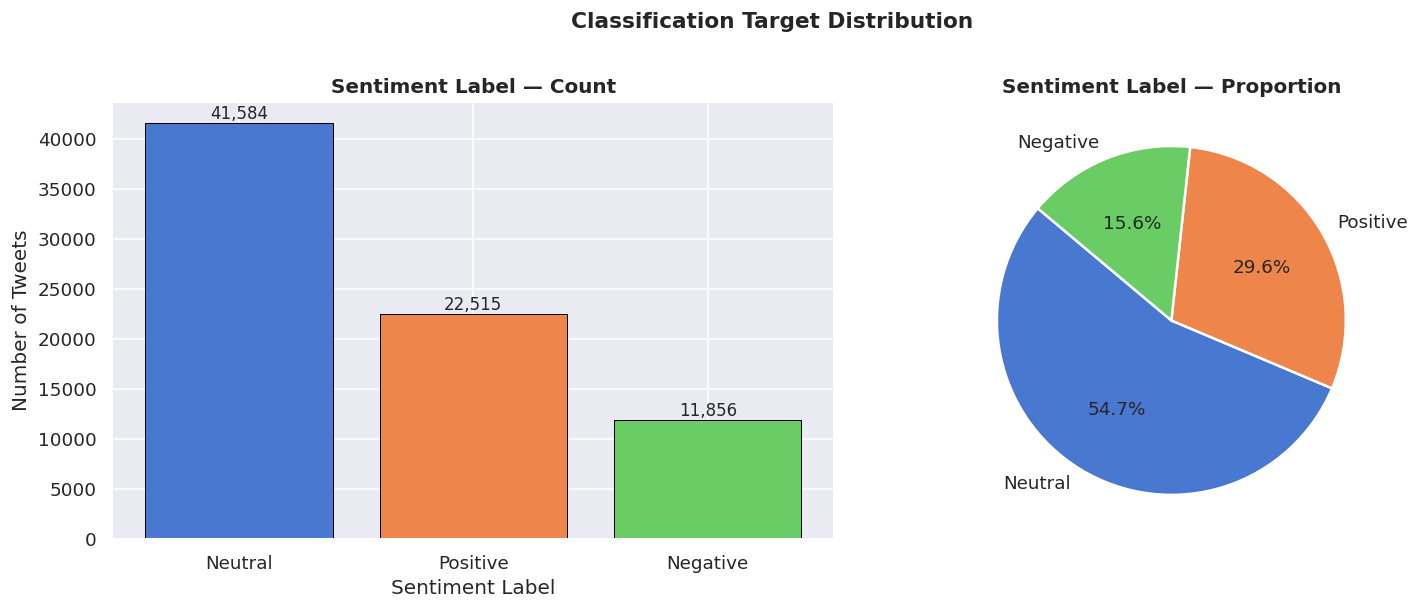

Imbalance ratio (max/min class): 3.51x
Significant imbalance detected. Consider class weighting or oversampling in training.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('muted', n_colors=len(label_counts))

axes[0].bar(label_counts.index.astype(str), label_counts.values,
            color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Sentiment Label — Count', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + max(label_counts.values)*0.01, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(
    label_counts.values,
    labels=label_counts.index.astype(str),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment Label — Proportion', fontweight='bold')

plt.suptitle('Classification Target Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

ratio = label_pct.max() / label_pct.min()
print(f'Imbalance ratio (max/min class): {ratio:.2f}x')
if ratio > 3:
    print('Significant imbalance detected. Consider class weighting or oversampling in training.')
else:
    print('Classes are relatively balanced.')

Distribucija labela je prilicno prirodna, ali nizak udeo Negative labele moze praviti problema buducem modelu da nauci obrazce vezane za ovu kategoriju. Zbog toga je preporucljivo koristiti class weighting kod loss funkcije.

In [16]:
score_series = df[SCORE_COL].dropna()

print('=== Sentiment Score Distribution ===')
print(f'\nSkewness : {score_series.skew():.4f}')
print(f'Kurtosis : {score_series.kurt():.4f}')

=== Sentiment Score Distribution ===

Skewness : 0.0513
Kurtosis : -1.1021


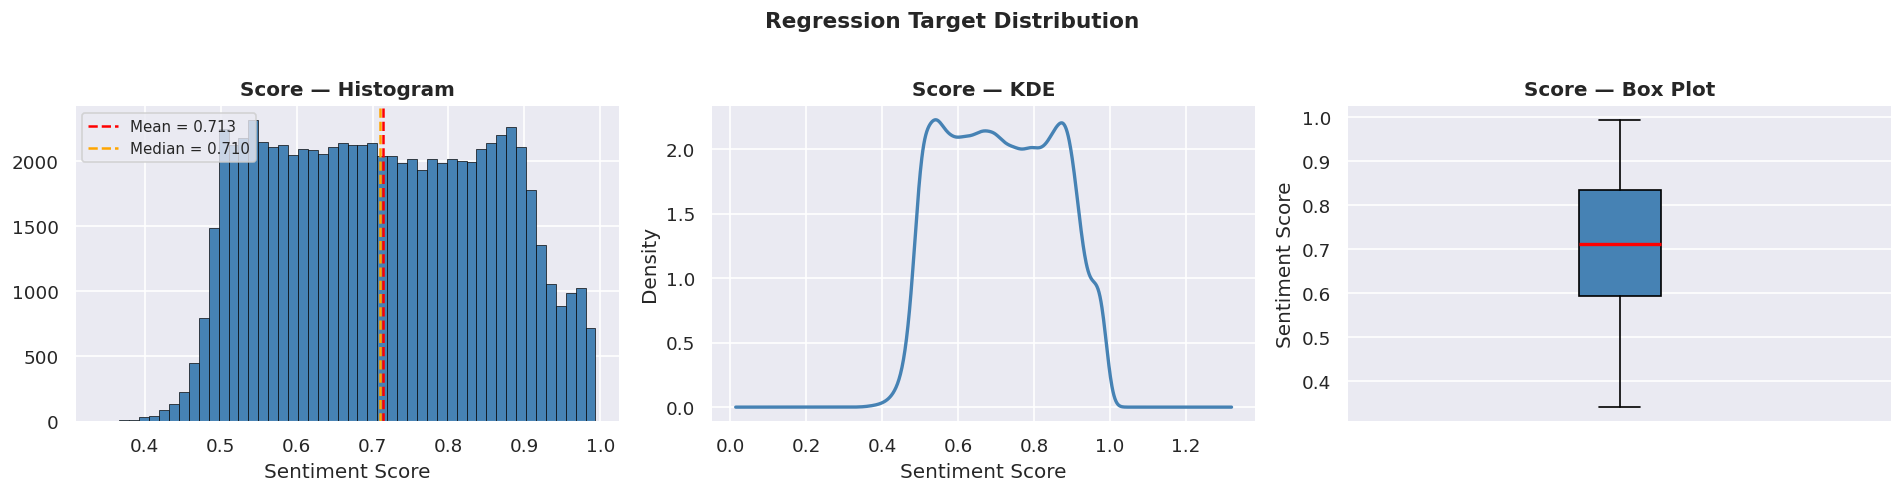

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(score_series, bins=50, color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].axvline(score_series.mean(), color='red', linestyle='--',
                label=f'Mean = {score_series.mean():.3f}')
axes[0].axvline(score_series.median(), color='orange', linestyle='--',
                label=f'Median = {score_series.median():.3f}')
axes[0].set_title('Score — Histogram', fontweight='bold')
axes[0].set_xlabel('Sentiment Score')
axes[0].legend(fontsize=9)

# KDE
score_series.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Score — KDE', fontweight='bold')
axes[1].set_xlabel('Sentiment Score')

# Box plot
axes[2].boxplot(score_series, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Score — Box Plot', fontweight='bold')
axes[2].set_ylabel('Sentiment Score')
axes[2].set_xticks([])

plt.suptitle('Regression Target Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Bimodalna distribucija sadrzi dva peak-a: oko 0.55 i 0.85. Ovo ukazuje na postojanje dve zone (klastera) u kojima je model bio manje i vise siguran. Takodje, box plot pokazuje da nema outliera, sto je dobro, narocito jer su mean i median u prakticno istoj tacki.

----------------------

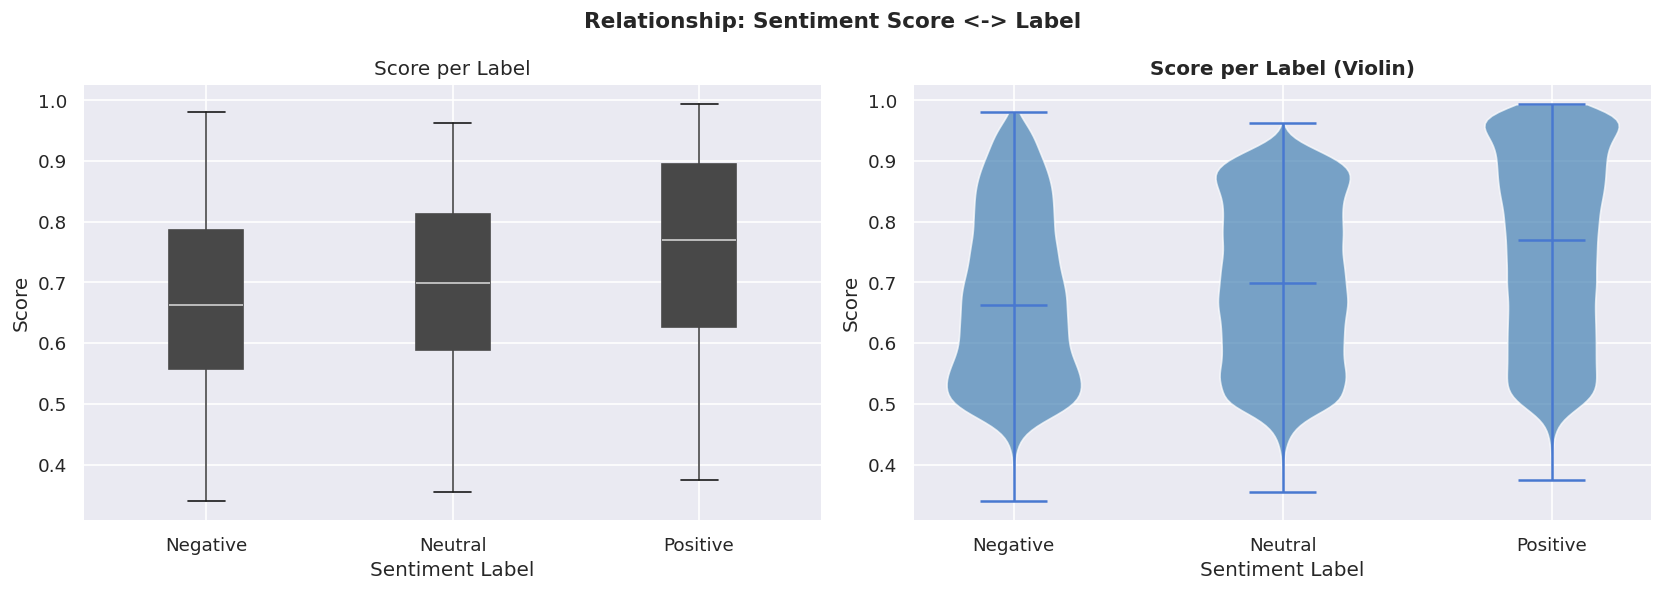

Mean score per class:
                   mean  median     std
sentiment_label                        
Negative         0.6767  0.6625  0.1362
Neutral          0.6992  0.6984  0.1304
Positive         0.7591  0.7698  0.1516


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column=SCORE_COL, by=LABEL_COL, ax=axes[0], patch_artist=True)
axes[0].set_title('Score per Label')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Score')
plt.sca(axes[0]); plt.title('Score per Label')

unique_labels = sorted(df[LABEL_COL].unique())
data_per_label = [df[df[LABEL_COL] == lbl][SCORE_COL].dropna().values for lbl in unique_labels]
parts = axes[1].violinplot(data_per_label, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.7)
axes[1].set_xticks(range(1, len(unique_labels) + 1))
axes[1].set_xticklabels([str(l) for l in unique_labels])
axes[1].set_title('Score per Label (Violin)', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Score')

plt.suptitle('Relationship: Sentiment Score <-> Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean score per class:')
print(df.groupby(LABEL_COL)[SCORE_COL].agg(['mean','median','std']).round(4))

Brojke imaju smisla, srednja vrednost raste od negativne ka pozitivnoj labeli. Medjutim, ta razlika nije numericki znacajna (0.2-0.5), a postoje i preklapanja izmedju vrednosti. Ovo ukazuje da kolona sentiment_score mozda i nije rezultat analize sentimenta, nego nesto drugo (recimo sigurnost u samo labeliranje). Sa druge strane, violin plot pokazuje da je vecina negativnih labela distribuirano oko manje vrednosti (0.5), neutralnih podjednako, a pozitivnih oko visoke vrednosti (0.95).


--------------------

In [19]:
df['tweet_len_chars'] = df[TEXT_COL].astype(str).apply(len)
df['tweet_len_words'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print('=== Tweet Length Statistics ===')
print(df[['tweet_len_chars','tweet_len_words']].describe().round(2))

=== Tweet Length Statistics ===
       tweet_len_chars  tweet_len_words
count         75955.00         75955.00
mean            153.45            23.41
std              85.45            13.87
min               4.00             1.00
25%              81.00            12.00
50%             132.00            20.00
75%             227.00            34.00
max             808.00           131.00


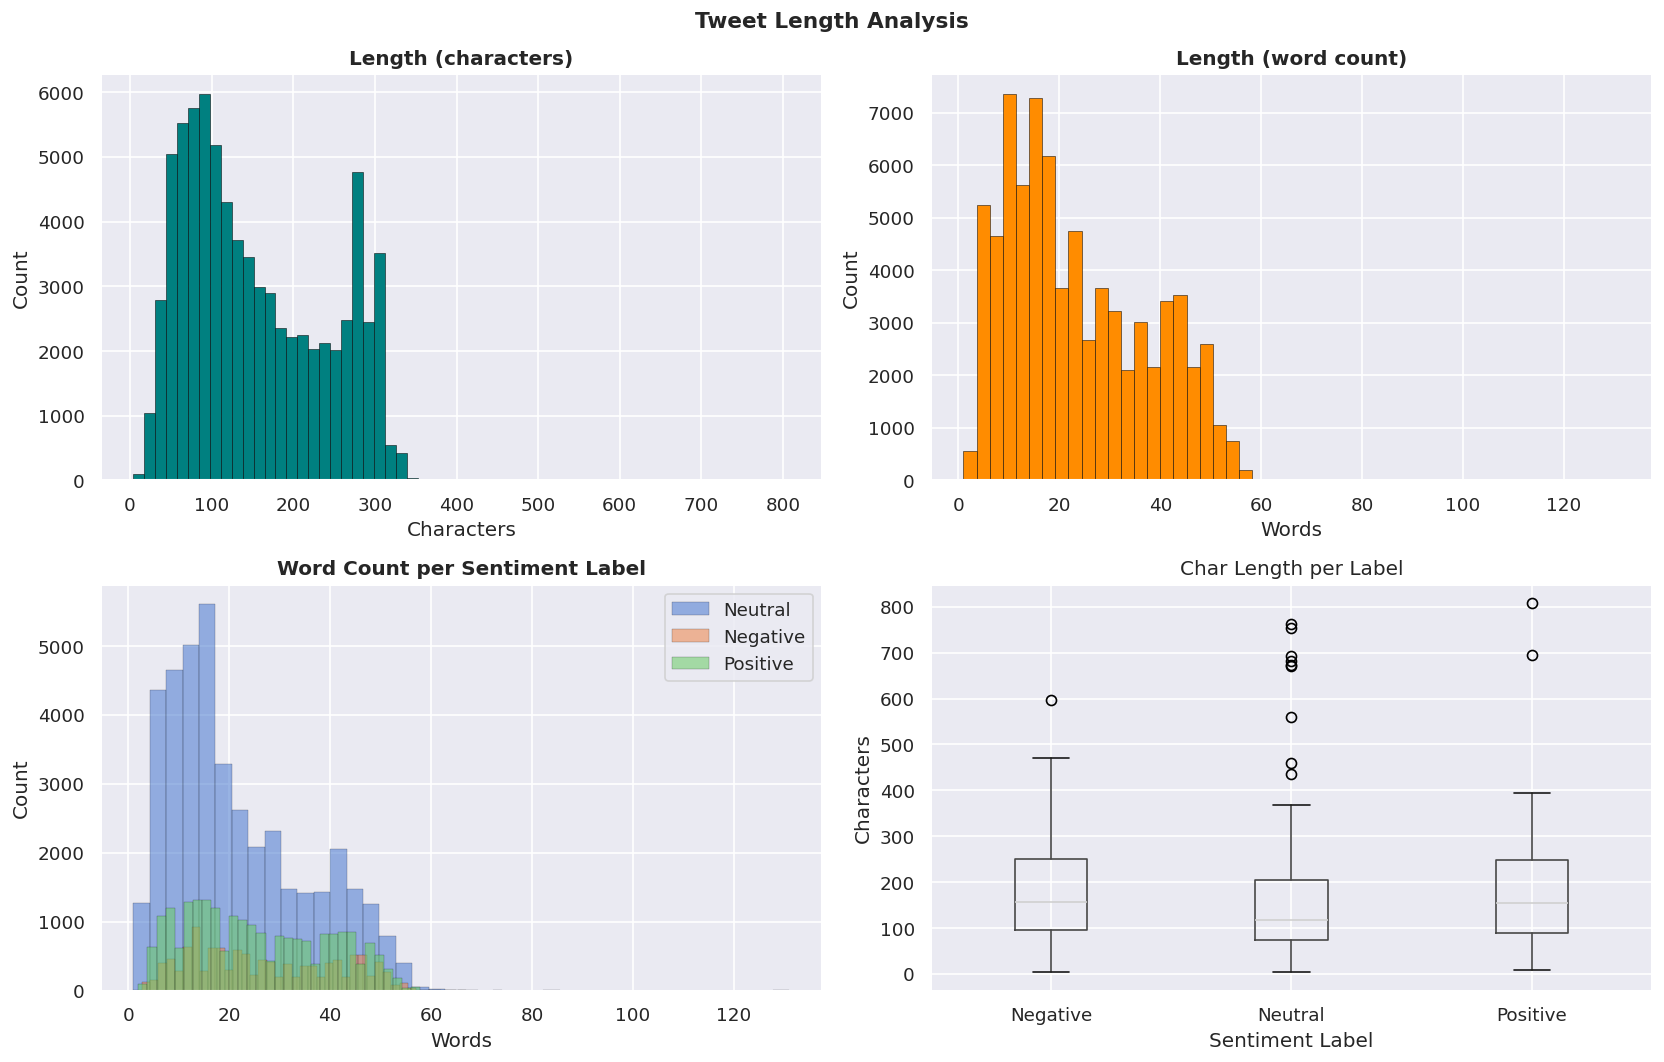

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0][0].hist(df['tweet_len_chars'], bins=60, color='teal', edgecolor='black', linewidth=0.3)
axes[0][0].set_title('Length (characters)', fontweight='bold')
axes[0][0].set_xlabel('Characters'); axes[0][0].set_ylabel('Count')

axes[0][1].hist(df['tweet_len_words'], bins=50, color='darkorange', edgecolor='black', linewidth=0.3)
axes[0][1].set_title('Length (word count)', fontweight='bold')
axes[0][1].set_xlabel('Words'); axes[0][1].set_ylabel('Count')

for label in df[LABEL_COL].unique():
    axes[1][0].hist(df[df[LABEL_COL]==label]['tweet_len_words'],
                   bins=40, alpha=0.55, label=str(label), edgecolor='black', linewidth=0.2)
axes[1][0].set_title('Word Count per Sentiment Label', fontweight='bold')
axes[1][0].set_xlabel('Words'); axes[1][0].set_ylabel('Count')
axes[1][0].legend()

df.boxplot(column='tweet_len_chars', by=LABEL_COL, ax=axes[1][1])
axes[1][1].set_title('Char Length per Label')
axes[1][1].set_xlabel('Sentiment Label'); axes[1][1].set_ylabel('Characters')
plt.sca(axes[1][1]); plt.title('Char Length per Label')

plt.suptitle('Tweet Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Maksimalna duzina tweeta iznosti 134 reci, dok je 75. kvantil ima vrednost od 34 reci. Ovo znaci da je barem 3/4 tweetova osrednje duzine, dok je mali procenat njih dugacak.

----------------

In [21]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','it',
    'this','that','with','was','are','be','as','by','from','i','my','me','we',
    'you','he','she','they','have','has','had','do','did','not','no','so',
    'if','its','just','will','can','all','up','what','rt','amp','bitcoin','btc'
}

def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

df['tokens_eda'] = df[TEXT_COL].apply(simple_clean)
df[[TEXT_COL, 'tokens_eda']].head(3)

,text,tokens_eda
0,Most people underestimate the impact #Bitcoin ...,"[most, people, underestimate, impact, individu..."
1,#Bitcoin has started a new yearly candle https...,"[started, new, yearly, candle]"
2,@DESTROYBINARY did people forget that the amog...,"[people, forget, amogus, meme, edit, never, cr..."


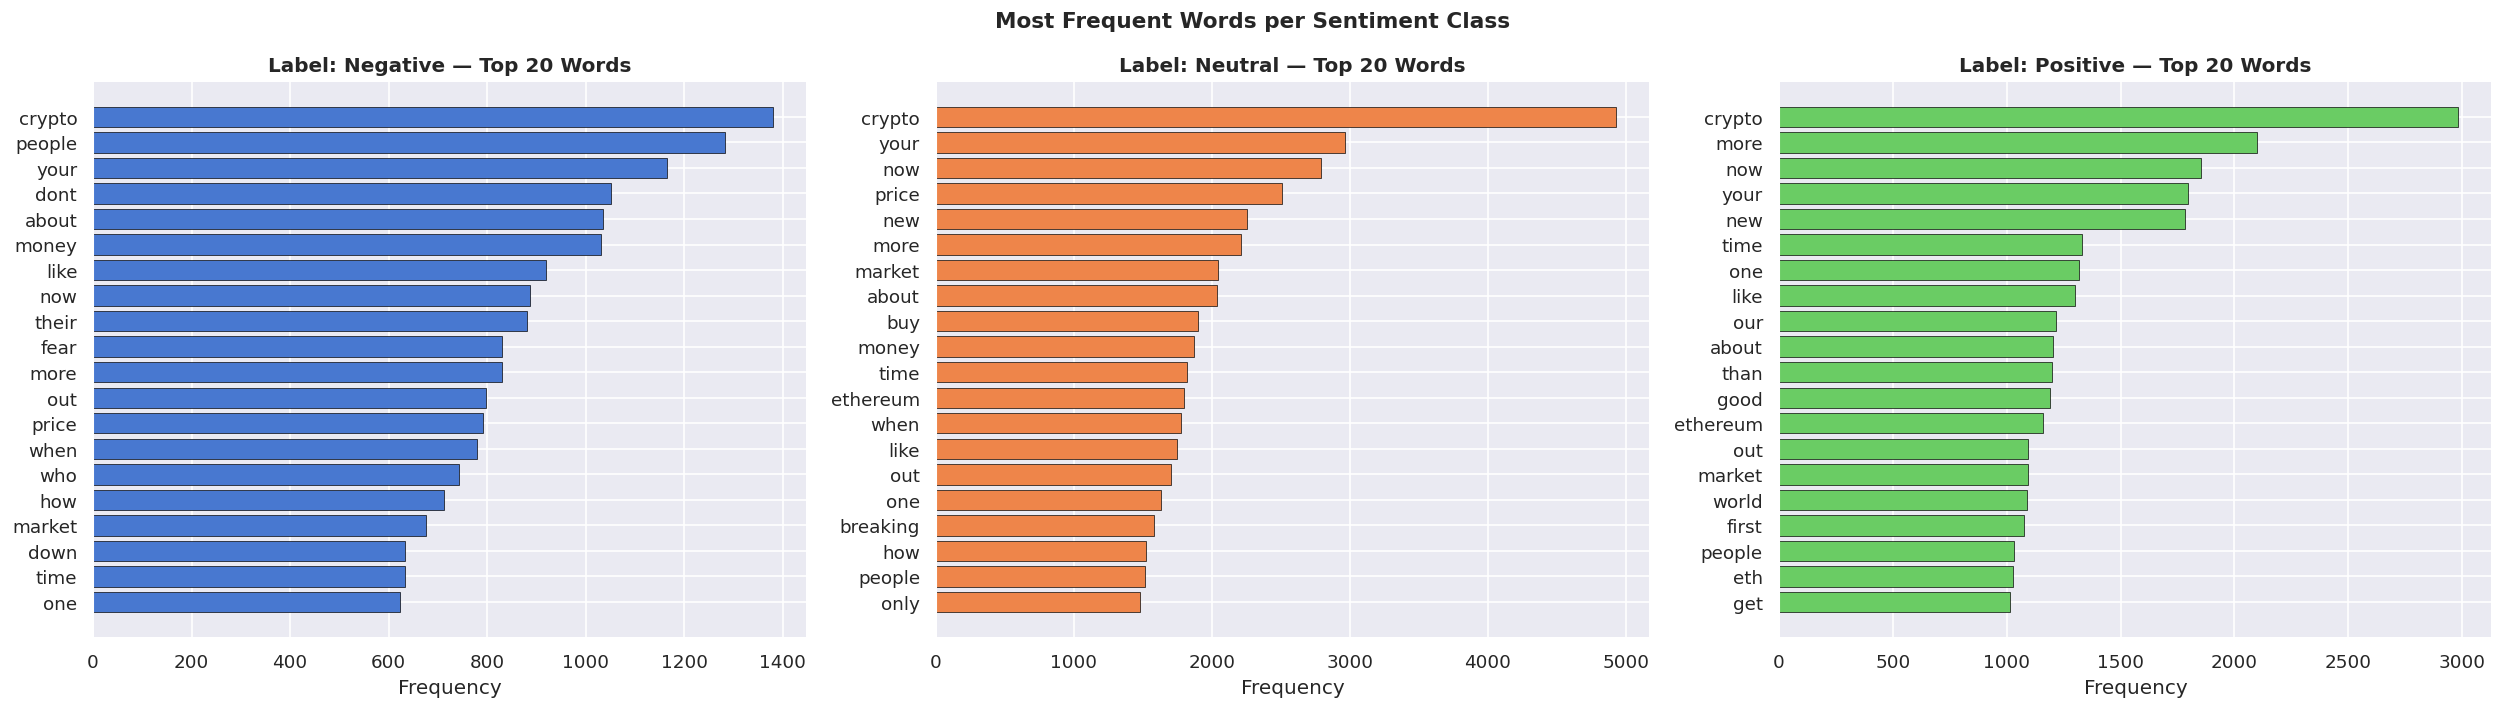

In [22]:
TOP_N = 20
fig, axes = plt.subplots(1, len(unique_labels), figsize=(7*len(unique_labels), 6))
if len(unique_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, unique_labels):
    tokens_flat = [t for row in df[df[LABEL_COL]==label]['tokens_eda'] for t in row]
    top_words = Counter(tokens_flat).most_common(TOP_N)
    if top_words:
        words, counts = zip(*top_words)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=sns.color_palette('muted')[unique_labels.index(label)],
                edgecolor='black', linewidth=0.4)
    ax.set_title(f'Label: {label} — Top {TOP_N} Words', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rec kao sto je dont ili down se cesto pojavljuje u Negative, dok se u Positive pojavljuju first, new, good.

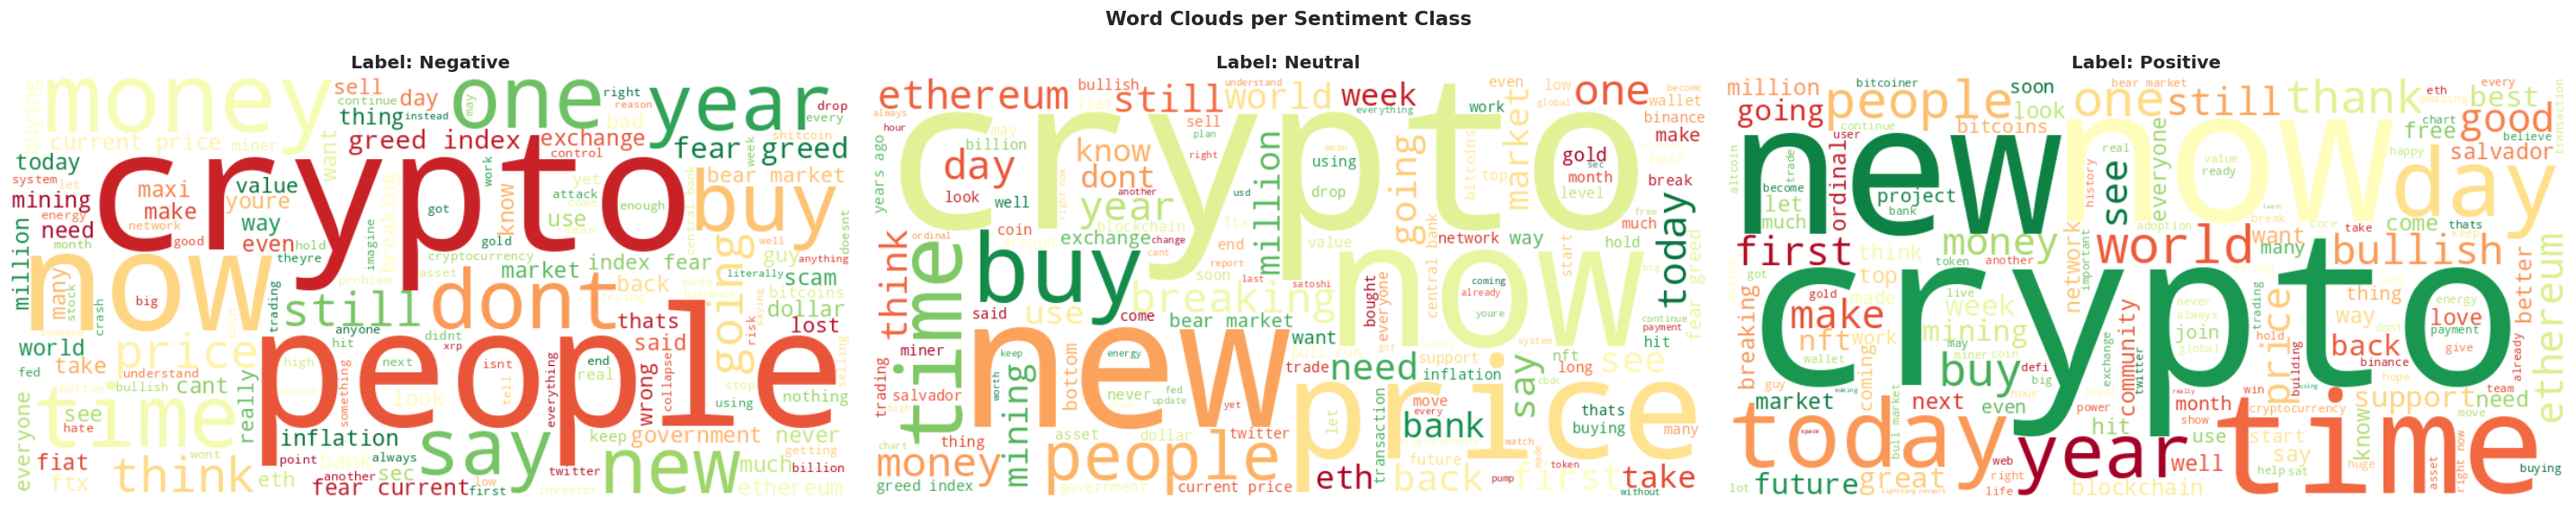

In [23]:
fig, axes = plt.subplots(1, len(unique_labels), figsize=(8*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]
for ax, label in zip(axes, unique_labels):
    tokens_flat = [t for row in df[df[LABEL_COL]==label]['tokens_eda'] for t in row]
    wc = WordCloud(width=800, height=400, background_color='white',
            colormap='RdYlGn', max_words=150).generate(' '.join(tokens_flat))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Label: {label}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Word Clouds per Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

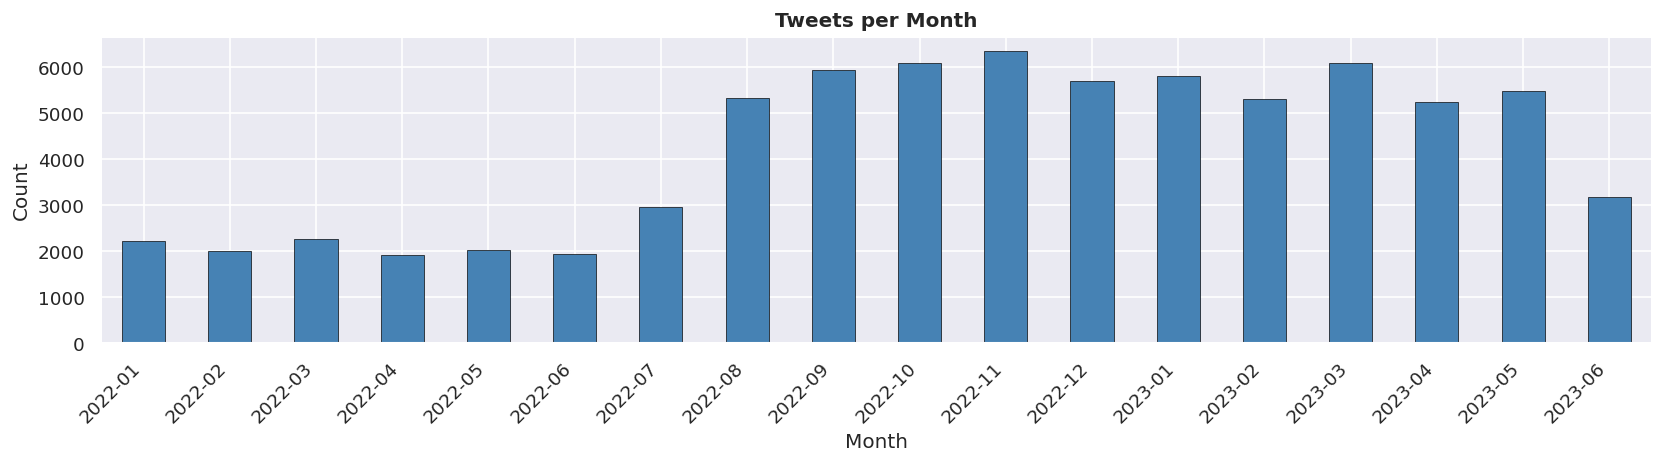

In [24]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')
fig, ax = plt.subplots(figsize=(14, 4))
df.groupby('month').size().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Tweets per Month', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Vidi se da je broj tweetova naglo porastao 08-2022. Verovatno je zapoceo trend o Bitcoinu koji je trajao sve do 06-2023.

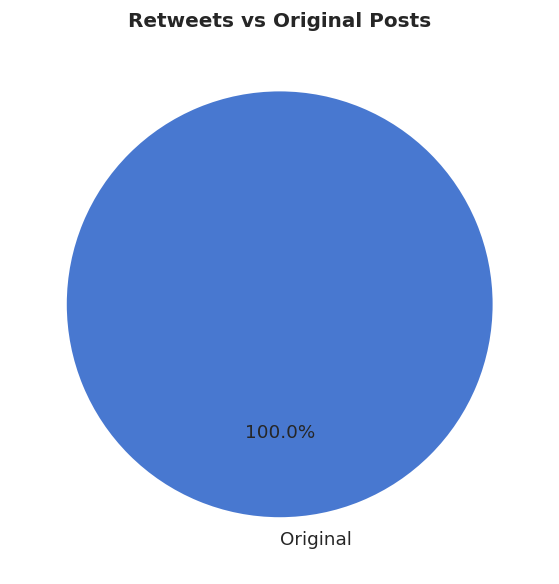

Retweets  : 0  (0.0%)
Originals : 75,955  (100.0%)


In [25]:
df['is_retweet'] = df[TEXT_COL].str.startswith('RT @')
rt_counts = df['is_retweet'].value_counts()
rt_labels = ['Retweet' if x else 'Original' for x in rt_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(rt_counts.values, labels=rt_labels, autopct='%1.1f%%',
       colors=sns.color_palette('muted', 2),
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
       startangle=90)
ax.set_title('Retweets vs Original Posts', fontweight='bold')
plt.tight_layout()
plt.show()

n_retweets  = df['is_retweet'].sum()
n_originals = (~df['is_retweet']).sum()
print(f"Retweets  : {n_retweets:,}  ({n_retweets/len(df)*100:.1f}%)")
print(f"Originals : {n_originals:,}  ({n_originals/len(df)*100:.1f}%)")

In [26]:
ENGAGEMENT_COLS = ['reply_count', 'like_count', 'retweet_count']
df['engagement_score'] = df[ENGAGEMENT_COLS].sum(axis=1)

print('=== TOP 5 Most Popular Tweets ===')
top5 = df.nlargest(5, 'engagement_score')[['text', 'sentiment_label', 'like_count', 'retweet_count', 'reply_count', 'engagement_score']]
pd.set_option('display.max_colwidth', 80)
print(top5.to_string(index=False))

print('\n=== TOP 5 Least Popular Tweets ===')
bot5 = df.nsmallest(5, 'engagement_score')[['text', 'sentiment_label', 'like_count', 'retweet_count', 'reply_count', 'engagement_score']]
print(bot5.to_string(index=False))

=== TOP 5 Most Popular Tweets ===
                                                                                                                                                                                                                                                                                                                                   text sentiment_label  like_count  retweet_count  reply_count  engagement_score
                                                                                                                                                                                                             Screaming and crying as a six year old trying to explain what bitcoin is to my parents mid-divorce https://t.co/CgaXZTuRHo        Negative      383127          39266         1208            423601
I FOUND THE EASTER EGG 🥚 \n\nI GUESS YOU GET SOMETHING AFTER ALL 🤑\n\nTHANK YOU ! @Pauly0x \n🔗 https://t.co/Xt67Evs3Nd\n\nTIP: You won't know If you've found it u

In [27]:
print(f"\nTweets with 0 quotes : {(df['quote_count']==0).sum():,}")
print(f"Tweets with 1+ quotes: {(df['quote_count']>0).sum():,}")
print(f"Max quote count      : {df['quote_count'].max():,}")
print(f"\n=== TOP 5 Most Quoted Tweets ===")
print(df.nlargest(5, 'quote_count')[['text', 'sentiment_label', 'quote_count']].to_string(index=False))


Tweets with 0 quotes : 12,021
Tweets with 1+ quotes: 63,934
Max quote count      : 45,401

=== TOP 5 Most Quoted Tweets ===
                                                                                                                                                                                                                                                                                                                text sentiment_label  quote_count
                                                                                                                                                                   Happy $50,000 in bitcoin. That’s what we’re giving away. Follow @cashapp and QRT with your $cashtag to enter. #CashAppDay https://t.co/bNUP326Lan        Positive        45401
                                                                                                                             It’s an extra special Cash App Friday because we’re giving away $10k in Bi

Dataset ne sadrzi ni jedan retweet - tweet koji zapocinje u formi RE@... <br>
Postoje tweetovi bez lajkova, komentara ili retwitova, ali je njihov sadrzaj teksta od znacaja za trening modela.<br>
Postoje i jako popularni tweetovi u datasetu, sto putem brojki, to i putem citiranja.

----------------------

# Text Preprocessing

In [28]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
negations = {'not', 'no', 'nor'}
STOPWORDS = STOPWORDS - negations

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


-----------------------------
## Preprocessing function:

In [29]:
def preprocess_tweet(text: str) -> str:
    text = unicodedata.normalize('NFKC', text)

    # ── 1. Lowercase
    text = str(text).lower()

    # ── 2. Remove URLs ──────
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # ── 3. Remove @mentions ─
    text = re.sub(r'@\w+', '', text)

    # ── 4. Remove # but keep the word ─────────────────────────
    text = re.sub(r'#(\w+)', r'\1', text)

    # ── 5. Remove $ but keep the word ─────────────────────────
    text = re.sub(r'\$(\w+)', r'\1', text)

    # ── 6. Remove emojis & unicode symbols ────────────────────
    text = ''.join(
        c for c in text
        if unicodedata.category(c) not in ('So', 'Sm', 'Sk', 'Sc')
        and ord(c) < 0x10000
    )

    # ── 7. Remove newlines & tabs ─────────────────────────────
    text = re.sub(r'[\n\r\t]', ' ', text)

    # ── 8. Remove punctuation & special characters ────────────
    #    Keep: letters, digits, spaces
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # ── 9. Remove stopwords ─
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]

    # ── 10. Remove extra whitespace ───────────────────────────
    text = ' '.join(tokens).strip()

    return text

print('preprocess_tweet() defined.')

preprocess_tweet() defined.


### Example

In [30]:
test_cases = [
    "#BITCOIN BOUNCING BACK! 🚀",
    "@DestroyBinary Bitcoin is going to ZERO https://t.co/XcHlHVDzUU",
    "$BTC\n\nBitcoin has a 99.98% uptime\nHigher than Google!",
    "In 2022, #Bitcoin crashed from $45,000 to $20,000 😢",
    "If your coin has a CEO… it's not your coin. Buy #Bitcoin instead.",
    "\"I would love #bitcoin to go lower because I would buy more\" -- Jordan Belfort @wolfofwallst"
]

print('=== Preprocessing Sanity Check ===\n')
for tweet in test_cases:
    cleaned = preprocess_tweet(tweet)
    print(f'  ORIGINAL : {tweet}')
    print(f'  CLEANED  : {cleaned}')
    print()

=== Preprocessing Sanity Check ===

  ORIGINAL : #BITCOIN BOUNCING BACK! 🚀
  CLEANED  : bitcoin bouncing back

  ORIGINAL : @DestroyBinary Bitcoin is going to ZERO https://t.co/XcHlHVDzUU
  CLEANED  : bitcoin going zero

  ORIGINAL : $BTC

Bitcoin has a 99.98% uptime
Higher than Google!
  CLEANED  : btc bitcoin 9998 uptime higher google

  ORIGINAL : In 2022, #Bitcoin crashed from $45,000 to $20,000 😢
  CLEANED  : 2022 bitcoin crashed 45000 20000

  ORIGINAL : If your coin has a CEO… it's not your coin. Buy #Bitcoin instead.
  CLEANED  : coin ceo not coin buy bitcoin instead

  ORIGINAL : "I would love #bitcoin to go lower because I would buy more" -- Jordan Belfort @wolfofwallst
  CLEANED  : would love bitcoin go lower would buy jordan belfort



### Full dataset

In [31]:
print('Preprocessing tweets...')
df['text_clean'] = df[TEXT_COL].apply(preprocess_tweet)
print(f'Done! {len(df):,} tweets processed.')

# Quick preview
df[[TEXT_COL, 'text_clean']].head(5)

Preprocessing tweets...
Done! 75,955 tweets processed.


,text,text_clean
0,Most people underestimate the impact #Bitcoin will have on individual sovere...,people underestimate impact bitcoin individual sovereignty personal freedom
1,#Bitcoin has started a new yearly candle https://t.co/XcHlHVDzUU,bitcoin started new yearly candle
2,@DESTROYBINARY did people forget that the amogus meme was an edit of a 'bitc...,people forget amogus meme edit bitcoin never crash comic made
3,"In 2017, miners attempted to assert control over the #Bitcoin protocol, and ...",2017 miners attempted assert control bitcoin protocol failed thanks bip148 u...
4,Yearly Close \nMonthly Close\nDaily Close\n\nhave all just taken place\n\nHa...,yearly close monthly close daily close taken place happy new year bitcoin im...


Licna imenica kao sto je Jordan Belfort je suvisna za obradu teksta, ali bi izbacivanjem licnih imenica mogao da izbacim i rec Bitcoin koja je glavna u datasetu.

### Proper nouns

In [32]:
def preprocess_tweet_keep_case(text: str) -> str:
    # Same as preprocess_tweet but skip the lowercase step
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\$(\w+)', r'\1', text)
    text = re.sub(r'[\n\r\t]', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # keep uppercase
    text = ' '.join(text.split()).strip()
    return text

df['text_cased'] = df['text'].apply(preprocess_tweet_keep_case)

In [33]:

proper_nouns = []
for tweet in df['text_cased']:
    tokens = word_tokenize(tweet)
    tagged = pos_tag(tokens)
    proper_nouns.extend([word for word, tag in tagged if tag == 'NNP'])

# Count and display
proper_noun_counts = Counter(proper_nouns)
print(f'Unique proper nouns found: {len(proper_noun_counts)}')
print('\nTop 50 most frequent:')
for word, count in proper_noun_counts.most_common(50):
    print(f'  {word:<20} {count:,}')


Unique proper nouns found: 26226

Top 50 most frequent:
  Bitcoin              54,368
  BTC                  8,433
  Crypto               3,027
  BITCOIN              2,798
  IN                   2,715
  Ethereum             2,551
  ETH                  2,206
  US                   2,053
  Im                   1,806
  Fear                 1,492
  El                   1,334
  BREAKING             1,330
  Binance              1,250
  A                    1,242
  Greed                1,141
  Salvador             1,140
  FTX                  1,067
  Index                991
  BNB                  991
  Current              938
  NFT                  916
  NEW                  856
  SEC                  845
  Dont                 824
  Satoshi              819
  CEO                  803
  Twitter              777
  Bank                 766
  Bitcoins             736
  NFTs                 729
  XRP                  691
  New                  690
  Buy                  629
  TO              

Kako je broj vlastitih imenica prevelik, ideja o izbacivanju odredjenih imenica ce biti preskocena.

### Post-Processing Quiality Check

### Prazni tweetovi

In [34]:
empty_mask = df['text_clean'].str.strip() == ''
print(f'Tweets that became empty after cleaning: {empty_mask.sum()}')

if empty_mask.sum() > 0:
    print('\nExamples of tweets that became empty:')
    print(df[empty_mask][TEXT_COL].head(10).to_string())

    df = df[~empty_mask].reset_index(drop=True)
    print(f'\nDropped. Remaining rows: {len(df):,}')

Tweets that became empty after cleaning: 10

Examples of tweets that became empty:
17306                   How we do? https://t.co/a9QFJZYFe0
17373    @BigBluexlt @brixwe More. https://t.co/SK4Wzdk5xL
28775                  We are here https://t.co/ibMcrSJ21y
32748             who? who? who? 👀 https://t.co/aFtHhhbsIF
38544                     @elonmusk @stillgray For the 💍 😂
39427                      More:👇\nhttps://t.co/Ec7RHJoTK6
57368                    It's over https://t.co/Uz7gLDZq3I
59575                      More 👇\nhttps://t.co/SIMerXcoay
60932                       This 👇 https://t.co/cWo5HGN3ao
70631                 Where is it? https://t.co/zT7rkPmV3G

Dropped. Remaining rows: 75,945


### Kratki tweetovi

In [35]:
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

print('=== Cleaned Tweet Length Statistics ===')
print(df['clean_word_count'].describe().round(2))

print(f'\nTweets with only 1 word : {(df["clean_word_count"] == 1).sum()}')
print(f'Tweets with only 2 words: {(df["clean_word_count"] == 2).sum()}')

# Show the 1-word tweets
one_word = df[df['clean_word_count'] == 1]
if len(one_word) > 0:
    print(f'\n=== 1-word tweets (showing up to 10) ===')
    print(one_word[[TEXT_COL, 'text_clean', LABEL_COL]].head(10).to_string())

=== Cleaned Tweet Length Statistics ===
count    75945.00
mean        13.79
std          8.35
min          1.00
25%          7.00
50%         12.00
75%         20.00
max         51.00
Name: clean_word_count, dtype: float64

Tweets with only 1 word : 244
Tweets with only 2 words: 1772

=== 1-word tweets (showing up to 10) ===
                                                        text text_clean sentiment_label
1303                                              Or Bitcoin    bitcoin         Neutral
2089                         Bitcoin https://t.co/3NqEoJSCiX    bitcoin         Neutral
3090                 Why we #Bitcoin https://t.co/zEbHIDkfvR    bitcoin         Neutral
3379                   #Bitcoin only https://t.co/AYTykyjm9Y    bitcoin         Neutral
3884   #BITCOIN: ALL IN!!!!!!!!!!!!! https://t.co/HLOjmkRs2Z    bitcoin        Positive
4301                                              Bitcoin 🇺🇸    bitcoin        Positive
5228                                               Bitcoi

Srdnja i maksimalna vrednost reci se prepolovila u tweetovima, sto direktno utice na maksimalnu duzinu sekvence koja ce kasnije biti potrebna pri vektorizaciji. Vidi se da postoji 244 tweetova koji sadrze samo jednu rec, a od toga su vecinom verovatno samo rec bitcoin. Ovakvi tweetovi ne znace nista za model i ne sadrze informaciju povezanu sa labelom.

In [36]:
before = len(df)
df = df[df['clean_word_count'] > 1].reset_index(drop=True)
print(f'Dropped {before - len(df)} one-word tweets.')
print(f'Remaining rows: {len(df):,}')

Dropped 244 one-word tweets.
Remaining rows: 75,701


In [37]:
MAX_SEQ_LEN = int(np.percentile(df['clean_word_count'], 95))
print(f'95th percentile word count (cleaned): {MAX_SEQ_LEN}')
print(f'This will be our MAX_SEQ_LEN for padding/truncation in Embedding.')

coverage = (df['clean_word_count'] <= MAX_SEQ_LEN).mean() * 100
print(f'Tweets covered at MAX_SEQ_LEN={MAX_SEQ_LEN}: {coverage:.1f}%')

95th percentile word count (cleaned): 29
This will be our MAX_SEQ_LEN for padding/truncation in Embedding.
Tweets covered at MAX_SEQ_LEN=29: 96.0%


### Lable Encoding

In [38]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id_to_label = {v: k for k, v in label_map.items()}

df['label_encoded'] = df[LABEL_COL].map(label_map)

print('Label mapping:')
for k, v in label_map.items():
    print(f'  {k} → {v}')

print(f'\nAny nulls in encoded labels: {df["label_encoded"].isnull().sum()}')
print(f'\nEncoded label distribution:')
print(df['label_encoded'].value_counts().sort_index())

Label mapping:
  Negative → 0
  Neutral → 1
  Positive → 2

Any nulls in encoded labels: 0

Encoded label distribution:
label_encoded
0    11842
1    41379
2    22480
Name: count, dtype: int64


### DataFrames Split

In [39]:
df_classification = df[['text_clean', 'label_encoded']].copy()
df_classification.columns = ['text', 'label']

df_regression = df[['text_clean', SCORE_COL]].copy()
df_regression.columns = ['text', 'score']

print(f'Classification df : {df_classification.shape}')
print(df_classification.head(3))

print(f'\nRegression df     : {df_regression.shape}')
print(df_regression.head(3))

Classification df : (75701, 2)
                                                                          text  \
0  people underestimate impact bitcoin individual sovereignty personal freedom   
1                                            bitcoin started new yearly candle   
2                people forget amogus meme edit bitcoin never crash comic made   

   label  
0      1  
1      1  
2      1  

Regression df     : (75701, 2)
                                                                          text  \
0  people underestimate impact bitcoin individual sovereignty personal freedom   
1                                            bitcoin started new yearly candle   
2                people forget amogus meme edit bitcoin never crash comic made   

      score  
0  0.717482  
1  0.810814  
2  0.606978  


---------------------

# Tokenization, Vocabulary Building & Splitting

### Train/Validation/Test split

In [40]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader


RANDOM_SEED = 18
VAL_SIZE    = 0.15
TEST_SIZE   = 0.15

def split_dataframe(df, val_size, test_size, seed, stratify_col=None):
    stratify = df[stratify_col] if stratify_col else None

    df_train_val, df_test = train_test_split(
        df, test_size=test_size, random_state=seed,
        shuffle=True, stratify=stratify
    )

    stratify_train_val = df_train_val[stratify_col] if stratify_col else None
    adjusted_val = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_train_val, test_size=adjusted_val, random_state=seed,
        shuffle=True, stratify=stratify_train_val
    )
    return df_train, df_val, df_test

train_cls, val_cls, test_cls = split_dataframe(df_classification, VAL_SIZE, TEST_SIZE, RANDOM_SEED, stratify_col='label')
train_reg, val_reg, test_reg = split_dataframe(df_regression, VAL_SIZE, TEST_SIZE, RANDOM_SEED)

print('=== Classification Split ===')
print(f'  Train : {len(train_cls):,}')
print(f'  Val   : {len(val_cls):,}')
print(f'  Test  : {len(test_cls):,}')
print(f'  Total : {len(train_cls) + len(val_cls) + len(test_cls):,}')

print('\n=== Regression Split ===')
print(f'  Train : {len(train_reg):,}')
print(f'  Val   : {len(val_reg):,}')
print(f'  Test  : {len(test_reg):,}')
print(f'  Total : {len(train_reg) + len(val_reg) + len(test_reg):,}')

# Verify label distribution is preserved across splits (stratification check)
print('\n=== Label Distribution in Splits (%) ===')
for name, split in [('Train', train_cls), ('Val', val_cls), ('Test', test_cls)]:
    dist = split['label'].value_counts(normalize=True) * 100
    print(f'  {name}: { {k: round(v,1) for k,v in dist.items()} }')


=== Classification Split ===
  Train : 52,990
  Val   : 11,355
  Test  : 11,356
  Total : 75,701

=== Regression Split ===
  Train : 52,990
  Val   : 11,355
  Test  : 11,356
  Total : 75,701

=== Label Distribution in Splits (%) ===
  Train: {1: 54.7, 2: 29.7, 0: 15.6}
  Val: {1: 54.7, 2: 29.7, 0: 15.6}
  Test: {1: 54.7, 2: 29.7, 0: 15.6}


----------------

In [41]:
MIN_FREQ = 2

word_counts = Counter(
    word
    for tweet in train_cls['text']
    for word in tweet.split()
)

print(f'Unique words in training set        : {len(word_counts):,}')
print(f'Words with freq >= {MIN_FREQ}               : {sum(1 for c in word_counts.values() if c >= MIN_FREQ):,}')
print(f'Words with freq == 1 (hapax)        : {sum(1 for c in word_counts.values() if c == 1):,}')

Unique words in training set        : 41,687
Words with freq >= 2               : 20,737
Words with freq == 1 (hapax)        : 20,950


### Index mapping

In [42]:
PAD_IDX = 0
UNK_IDX = 1

vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}

for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'Vocabulary size (including <PAD> and <UNK>): {VOCAB_SIZE:,}')

# Reverse mapping: index → word (useful for debugging later)
idx_to_word = {idx: word for word, idx in vocab.items()}

Vocabulary size (including <PAD> and <UNK>): 20,739


### Text to int

In [43]:
def tokenize(text: str, vocab: dict, unk_idx: int) -> list:
    return [vocab.get(word, unk_idx) for word in text.split()]

# Test it
sample = train_cls['text'].iloc[0]
print(f'Text    : {sample}')
print(f'Indices : {tokenize(sample, vocab, UNK_IDX)}')

Text    : waiting basically free web3 cryptocurency bullish bullrun bitcoin blockchain crypto ethereum bnb playtoearn cryptogaming
Indices : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1]


In [44]:
def unk_rate(df, vocab, unk_idx):
    total_tokens = 0
    unk_tokens   = 0
    for tweet in df['text']:
        indices = tokenize(tweet, vocab, unk_idx)
        total_tokens += len(indices)
        unk_tokens   += indices.count(unk_idx)
    return unk_tokens / total_tokens * 100

unk_val  = unk_rate(val_cls,  vocab, UNK_IDX)
unk_test = unk_rate(test_cls, vocab, UNK_IDX)

print(f'<UNK> rate — Val  set: {unk_val:.2f}%')
print(f'<UNK> rate — Test set: {unk_test:.2f}%')

<UNK> rate — Val  set: 4.52%
<UNK> rate — Test set: 4.31%


Vidi se da su vecina reci poznate iz recnika u oba skupa (trening i validacioni).

### Padding and Truncation

In [45]:
def pad_or_truncate(indices: list, max_len: int, pad_idx: int) -> list:

    if len(indices) < max_len:
        return [pad_idx] * (max_len - len(indices)) + indices
    else:
        return indices[-max_len:]

sample_indices = tokenize(sample, vocab, UNK_IDX)
padded = pad_or_truncate(sample_indices, MAX_SEQ_LEN, PAD_IDX)
print(f'Original length : {len(sample_indices)}')
print(f'Padded sequence : {padded}')
print(f'Padded length   : {len(padded)}')

Original length : 14
Padded sequence : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1]
Padded length   : 29


### Dataset + DataLoader

In [46]:
class TweetDataset(Dataset):
    def __init__(self, df, vocab, max_len, pad_idx, unk_idx, task='classification'):
        """
        Args:
            df      : dataframe with 'text' and either 'label' or 'score' column
            vocab   : word → index dictionary
            max_len : MAX_SEQ_LEN
            pad_idx : index for <PAD>
            unk_idx : index for <UNK>
            task    : 'classification' or 'regression'
        """
        self.task    = task
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.vocab   = vocab

        # Pre-process all sequences once at init time
        self.sequences = [
            pad_or_truncate(tokenize(text, vocab, unk_idx), max_len, pad_idx)
            for text in df['text']
        ]

        if task == 'classification':
            self.targets = df['label'].tolist()
        else:
            self.targets = df['score'].tolist()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)

        if self.task == 'classification':
            y = torch.tensor(self.targets[idx], dtype=torch.long)
        else:
            y = torch.tensor(self.targets[idx], dtype=torch.float)

        return x, y

print('TweetDataset class defined.')

TweetDataset class defined.


In [47]:
BATCH_SIZE = 64

# Classification datasets
train_cls_dataset = TweetDataset(train_cls, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')
val_cls_dataset   = TweetDataset(val_cls,   vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')
test_cls_dataset  = TweetDataset(test_cls,  vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')

# Regression datasets
train_reg_dataset = TweetDataset(train_reg, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')
val_reg_dataset   = TweetDataset(val_reg,   vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')
test_reg_dataset  = TweetDataset(test_reg,  vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')

# DataLoaders
train_cls_loader = DataLoader(train_cls_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_cls_loader   = DataLoader(val_cls_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_cls_loader  = DataLoader(test_cls_dataset,  batch_size=BATCH_SIZE, shuffle=False)

train_reg_loader = DataLoader(train_reg_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_reg_loader   = DataLoader(val_reg_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_reg_loader  = DataLoader(test_reg_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('=== Datasets & DataLoaders created ===')
print(f'  Classification — Train: {len(train_cls_dataset):,} | Val: {len(val_cls_dataset):,} | Test: {len(test_cls_dataset):,}')
print(f'  Regression     — Train: {len(train_reg_dataset):,} | Val: {len(val_reg_dataset):,} | Test: {len(test_reg_dataset):,}')
print(f'  Batch size: {BATCH_SIZE}')

=== Datasets & DataLoaders created ===
  Classification — Train: 52,990 | Val: 11,355 | Test: 11,356
  Regression     — Train: 52,990 | Val: 11,355 | Test: 11,356
  Batch size: 64


In [48]:
x_batch, y_batch = next(iter(train_cls_loader))

print('=== Single Batch Inspection (Classification) ===')
print(f'  x shape : {x_batch.shape}')
print(f'  y shape : {y_batch.shape} ')
print(f'  x dtype : {x_batch.dtype}')
print(f'  y dtype : {y_batch.dtype}')
print(f'\n  First sequence in batch:')
print(f'  Indices : {x_batch[0].tolist()}')
print(f'  Words   : {[idx_to_word[i.item()] for i in x_batch[0]]}')
print(f'  Label   : {y_batch[0].item()} ({id_to_label[y_batch[0].item()]})')

=== Single Batch Inspection (Classification) ===
  x shape : torch.Size([64, 29])
  y shape : torch.Size([64]) 
  x dtype : torch.int64
  y dtype : torch.int64

  First sequence in batch:
  Indices : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1777, 381, 1249, 238, 177, 337, 9, 2127, 390, 298, 67]
  Words   : ['<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'number', '1', 'reason', 'people', 'dont', 'like', 'bitcoin', 'maximalists', 'cant', 'make', 'money']
  Label   : 0 (Negative)


# Model Building (LSTM, GRU, CNN)

In [49]:
EMBED_DIM    = 128
HIDDEN_DIM   = 128
NUM_LAYERS   = 2
DROPOUT      = 0.0
NUM_FILTERS  = 128
KERNEL_SIZES = [2, 3, 4]
NUM_CLASSES  = 3

## LSTM

In [50]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 dropout, pad_idx, num_classes, task='classification'):
        super(LSTMModel, self).__init__()

        self.task       = task
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx    = pad_idx
        )

        # LSTM layer
        # instead of default (seq_len, batch, features)
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(hidden_dim, num_classes)
        else:
            self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]

        # Dropout
        out = self.dropout(last_hidden)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('LSTMModel defined.')

LSTMModel defined.


## GRU

In [51]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 dropout, pad_idx, num_classes, task='classification'):
        super(GRUModel, self).__init__()

        self.task       = task
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx    = pad_idx
        )

        # GRU layer (no cell state)
        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(hidden_dim, num_classes)
        else:
            self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)

        # GRU
        gru_out, hidden = self.gru(embedded)

        last_hidden = hidden[-1]

        # Dropout
        out = self.dropout(last_hidden)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('GRUModel defined.')

GRUModel defined.


## CNN

In [52]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes,
                 dropout, pad_idx, num_classes, task='classification'):
        super(CNNModel, self).__init__()

        self.task = task

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx    = pad_idx
        )

        # Convolutional layers (one per kernel size)
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels  = embed_dim,
                out_channels = num_filters,
                kernel_size  = k
            )
            for k in kernel_sizes
        ])

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)
        else:
            self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        embedded = embedded.permute(0, 2, 1)

        # Convolution + ReLU + Max Pooling
        pooled_outputs = []
        for conv in self.convs:
            conv_out = torch.relu(conv(embedded))

            pooled = torch.max(conv_out, dim=2).values

            pooled_outputs.append(pooled)

        cat = torch.cat(pooled_outputs, dim=1)

        # Dropout
        out = self.dropout(cat)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('CNNModel defined.')

CNNModel defined.


## Instantion of the models

### Classification

In [53]:
lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

### Regression

In [54]:
lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

---------------

In [55]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== Trainable Parameters ===')
print(f'  LSTM Classification : {count_parameters(lstm_cls):,}')
print(f'  LSTM Regression     : {count_parameters(lstm_reg):,}')
print(f'  GRU  Classification : {count_parameters(gru_cls):,}')
print(f'  GRU  Regression     : {count_parameters(gru_reg):,}')
print(f'  CNN  Classification : {count_parameters(cnn_cls):,}')
print(f'  CNN  Regression     : {count_parameters(cnn_reg):,}')

=== Trainable Parameters ===
  LSTM Classification : 2,919,171
  LSTM Regression     : 2,918,913
  GRU  Classification : 2,853,123
  GRU  Regression     : 2,852,865
  CNN  Classification : 2,803,587
  CNN  Regression     : 2,802,817


Razlika izmedju LSTM Classification i LSTM Regression je 258 parametara, sto je upravo razlika u broju izlaznih klasa (387-129). <br>
LSTM > GRU > CNN - broj parametara je logicki srazmeran tipu mreze, zbog broja gate-ova. <br>
Vecina parametara dolazi iz embedding sloja: VOCAB_SIZE × EMBED_DIM = 20,739 × 128 = 2,654,592 parametara (91%).

---------------------

In [56]:
x_batch, y_batch = next(iter(train_cls_loader))

print('=== Forward Pass Sanity Check ===')
print(f'Input shape: {x_batch.shape}')

with torch.no_grad():
    out_lstm = lstm_cls(x_batch)
    out_gru  = gru_cls(x_batch)
    out_cnn  = cnn_cls(x_batch)

print(f'\nLSTM output shape : {out_lstm.shape}  (expected: [64, 3])')
print(f'GRU  output shape : {out_gru.shape}  (expected: [64, 3])')
print(f'CNN  output shape : {out_cnn.shape}  (expected: [64, 3])')

print(f'\nLSTM first sample output : {out_lstm[0].tolist()}')
print(f'GRU  first sample output : {out_gru[0].tolist()}')
print(f'CNN  first sample output : {out_cnn[0].tolist()}')

=== Forward Pass Sanity Check ===
Input shape: torch.Size([64, 29])

LSTM output shape : torch.Size([64, 3])  (expected: [64, 3])
GRU  output shape : torch.Size([64, 3])  (expected: [64, 3])
CNN  output shape : torch.Size([64, 3])  (expected: [64, 3])

LSTM first sample output : [0.01208111084997654, 0.037735436111688614, 0.09923766553401947]
GRU  first sample output : [0.0014493931084871292, 0.013799190521240234, 0.039217736572027206]
CNN  first sample output : [0.2131125032901764, 0.10121001303195953, 0.6441275477409363]


Sva tri modela su predvidela labelu Neutral. To se desilo random, verovatno kao posledica najveceg procentualnog udela ove labele.

---------------------------------

# Training

In [57]:
from sklearn.metrics import f1_score, accuracy_score
import time

# Training Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS    = 10
VAL_CHECKS    = 3

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Loss Functions

In [58]:
classification_criterion = nn.CrossEntropyLoss()
regression_criterion     = nn.MSELoss()

### Training and Validation

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device, task):

    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        optimizer.zero_grad()
        predictions = model(x_batch)

        # Loss calculation
        loss = criterion(predictions, y_batch)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device, task):

    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)
            loss        = criterion(predictions, y_batch)
            total_loss += loss.item()

            if task == 'classification':
                preds = torch.argmax(predictions, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
            else:
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)

    if task == 'classification':
        accuracy = accuracy_score(all_labels, all_preds)
        f1       = f1_score(all_labels, all_preds, average='weighted')
        return avg_loss, accuracy, f1
    else:
        mae = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)))
        return avg_loss, mae

print('train_one_epoch() and evaluate() defined.')

train_one_epoch() and evaluate() defined.


In [60]:
def train_model(model, train_loader, val_loader, task,
                num_epochs, learning_rate, val_checks, device):

    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Loss function
    criterion = classification_criterion if task == 'classification' else regression_criterion

    # Tracking
    history = {
        'train_loss' : [],
        'val_loss'   : [],
        'val_metric1': [],
        'val_metric2': [],
    }

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    print(f'\n{"="*60}')
    print(f'  Task: {task.upper()}')
    print(f'  Model: {model.__class__.__name__}')
    print(f'  Device: {device}')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        # Training phase
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, task
        )

        # Validation phase
        if task == 'classification':
            val_loss, val_acc, val_f1 = evaluate(
                model, val_loader, criterion, device, task
            )
            history['val_metric1'].append(val_acc)
            history['val_metric2'].append(val_f1)
            metric_str = f'Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}'
        else:
            val_loss, val_mae = evaluate(
                model, val_loader, criterion, device, task
            )
            history['val_metric1'].append(val_mae)
            metric_str = f'Val MAE: {val_mae:.4f}'

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        elapsed = time.time() - start_time

        print(f'Epoch {epoch:02d}/{num_epochs} | '
              f'Time: {elapsed:.1f}s | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'{metric_str}')

        # Early stopping & best model saving
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            print(f'           Val loss improved → best model saved')
        else:
            patience_count += 1
            print(f'             No improvement ({patience_count}/{val_checks})')
            if patience_count >= val_checks:
                print(f'\n Early stopping triggered at epoch {epoch}')
                break

    print(f'\nBest val loss: {best_val_loss:.4f}')
    print(f'{"="*60}\n')

    return history, best_state

print('train_model() defined.')

train_model() defined.


In [61]:
lstm_cls = lstm_cls.to(device)
lstm_reg = lstm_reg.to(device)
gru_cls  = gru_cls.to(device)
gru_reg  = gru_reg.to(device)
cnn_cls  = cnn_cls.to(device)
cnn_reg  = cnn_reg.to(device)

# Classification models
print('Training LSTM Classification...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Classification...')
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Classification...')
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

# Regression models
print('Training LSTM Regression...')
hist_lstm_reg, best_lstm_reg = train_model(
    lstm_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Regression...')
hist_gru_reg, best_gru_reg = train_model(
    gru_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Regression...')
hist_cnn_reg, best_cnn_reg = train_model(
    cnn_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('\nAll 6 models trained!')

Training LSTM Classification...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 5.0s | Train Loss: 0.8521 | Val Loss: 0.7836 | Val Acc: 0.6397 | Val F1: 0.6270
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.1s | Train Loss: 0.6580 | Val Loss: 0.7132 | Val Acc: 0.6829 | Val F1: 0.6728
           Val loss improved → best model saved
Epoch 03/10 | Time: 4.8s | Train Loss: 0.5271 | Val Loss: 0.7184 | Val Acc: 0.6919 | Val F1: 0.6859
             No improvement (1/3)
Epoch 04/10 | Time: 4.1s | Train Loss: 0.4009 | Val Loss: 0.8071 | Val Acc: 0.6988 | Val F1: 0.6952
             No improvement (2/3)
Epoch 05/10 | Time: 4.1s | Train Loss: 0.2830 | Val Loss: 0.9273 | Val Acc: 0.6907 | Val F1: 0.6889
             No improvement (3/3)

 Early stopping triggered at epoch 5

Best val loss: 0.7132

Training GRU Classification...

  Task: CLASSIFICATION
  Model: GRUModel
  Device: cuda
Epoch 01/10 | Time: 4.6s | Train Loss: 0.8370 | Val Loss: 0.74

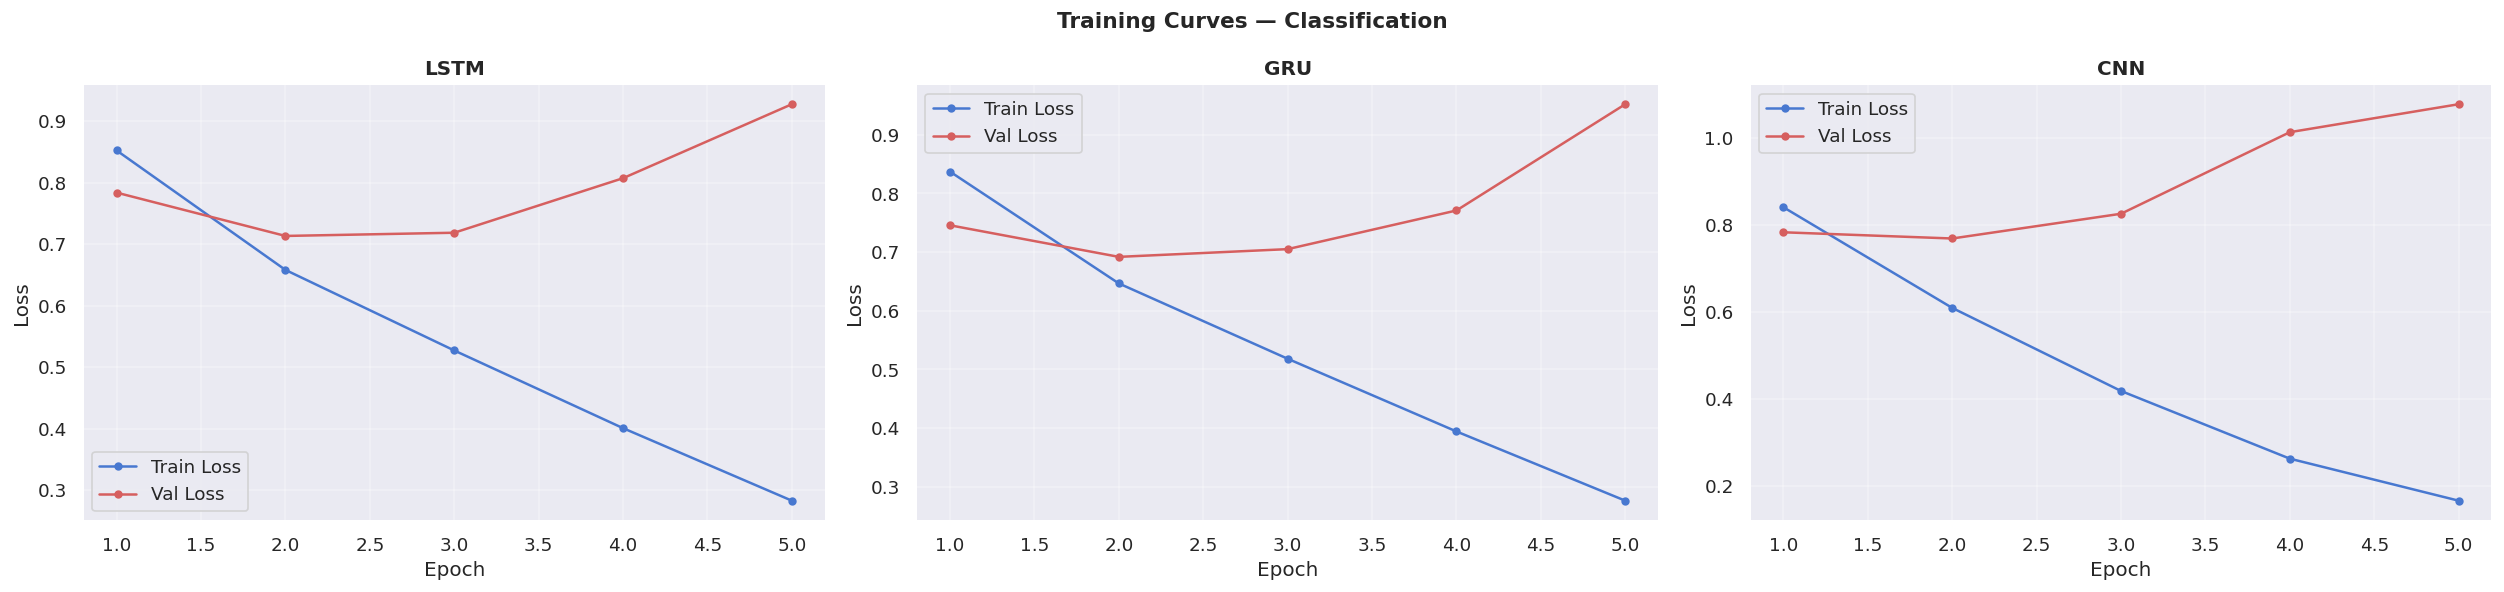

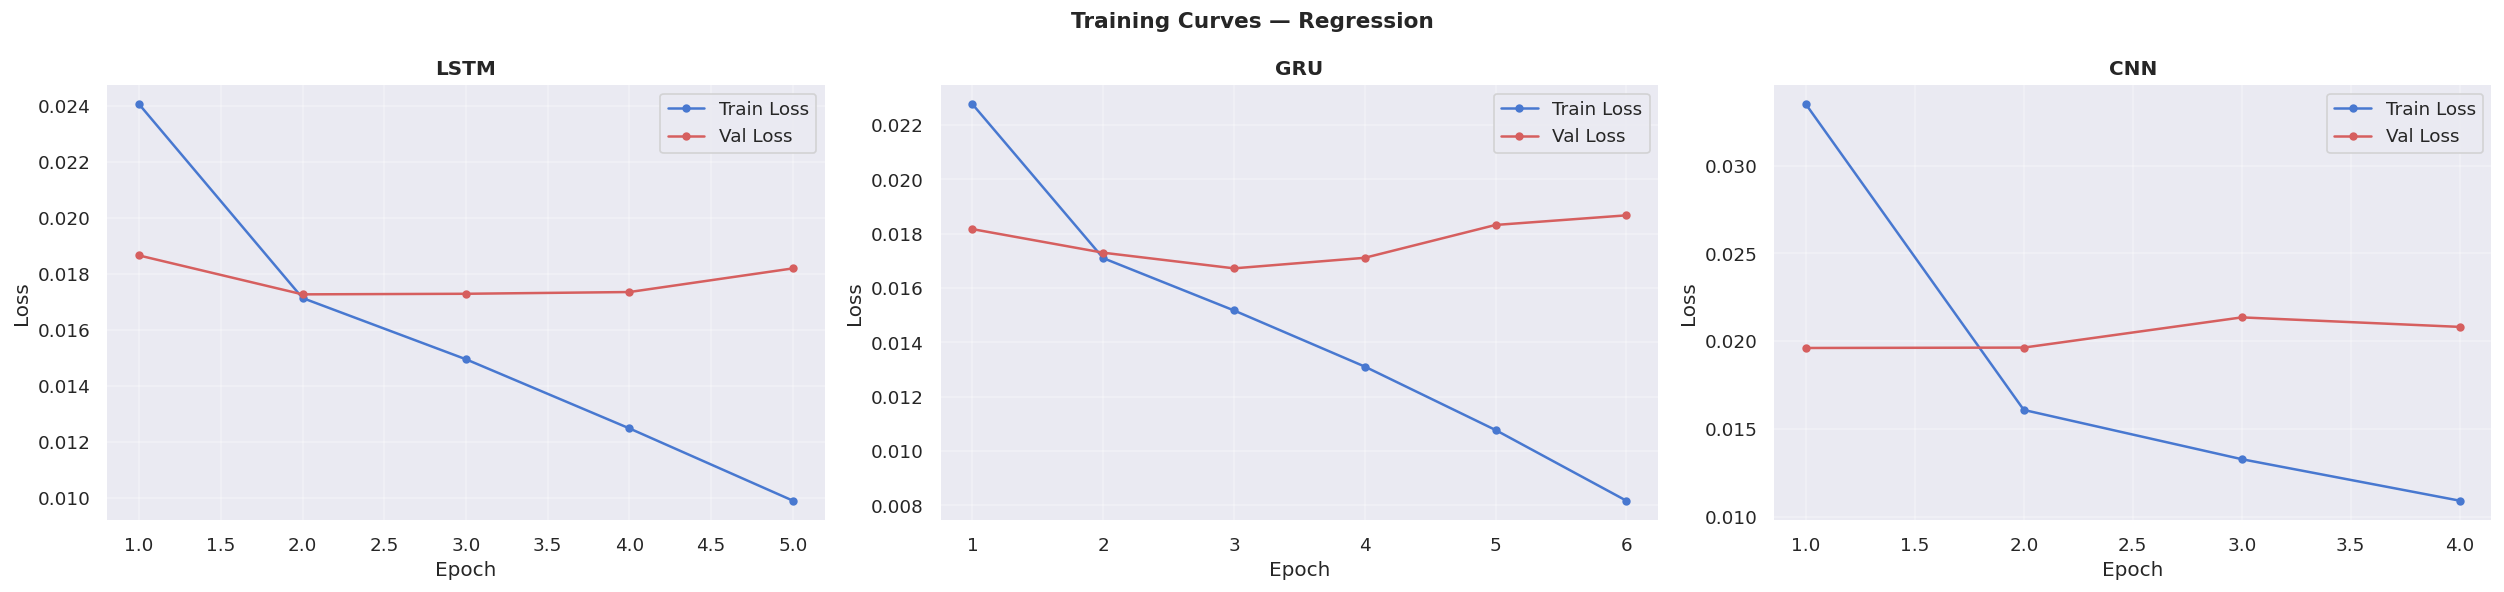

In [62]:
def plot_training_curves(histories, names, task):

    fig, axes = plt.subplots(1, len(histories), figsize=(7 * len(histories), 5))
    if len(histories) == 1:
        axes = [axes]

    for ax, history, name in zip(axes, histories, names):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        ax.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
        ax.set_title(f'{name}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Training Curves — {task.capitalize()}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Classification curves
plot_training_curves(
    [hist_lstm_cls, hist_gru_cls, hist_cnn_cls],
    ['LSTM', 'GRU', 'CNN'],
    task='classification'
)

# Regression curves
plot_training_curves(
    [hist_lstm_reg, hist_gru_reg, hist_cnn_reg],
    ['LSTM', 'GRU', 'CNN'],
    task='regression'
)

LSTM i GRU su dali veoma slicne rezultate, sto ukazuje da je GRU bolji izbor za zadati problem, jer je jednostavniji model (brze izvrsavanje pograma). Ovo i nije iznenadjujuce, jer su tweetovi u proseku male duzine, pa kompleksnost LSTM modela gubi na korisnosti. Grafici pokazuju klasican primer overfittinga, gde se gubitak validacije konstantno povecava, a greska treninga smanjuje. U poslednjoj, 5-oj epohi, razlika izmedju gubitaka je 0.6527 (klasifikacija).


------------------

Zbog prethodno ustanovljenog overfittinga, ubacice se dropout, odnosno povecace se njegova vrednost koja je inicijalno postavljena na 0.

In [63]:
DROPOUT = 0.5

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

In [64]:
print('Training LSTM Classification...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Classification...')
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Classification...')
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training LSTM Regression...')
hist_lstm_reg, best_lstm_reg = train_model(
    lstm_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Regression...')
hist_gru_reg, best_gru_reg = train_model(
    gru_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Regression...')
hist_cnn_reg, best_cnn_reg = train_model(
    cnn_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('\nAll 6 models retrained with Dropout!')

Training LSTM Classification...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 5.2s | Train Loss: 0.8697 | Val Loss: 0.7729 | Val Acc: 0.6477 | Val F1: 0.6349
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.5s | Train Loss: 0.6916 | Val Loss: 0.7318 | Val Acc: 0.6834 | Val F1: 0.6734
           Val loss improved → best model saved
Epoch 03/10 | Time: 5.0s | Train Loss: 0.5734 | Val Loss: 0.7079 | Val Acc: 0.6902 | Val F1: 0.6851
           Val loss improved → best model saved
Epoch 04/10 | Time: 4.6s | Train Loss: 0.4763 | Val Loss: 0.7551 | Val Acc: 0.6972 | Val F1: 0.6934
             No improvement (1/3)
Epoch 05/10 | Time: 4.5s | Train Loss: 0.3866 | Val Loss: 0.8078 | Val Acc: 0.7049 | Val F1: 0.7015
             No improvement (2/3)
Epoch 06/10 | Time: 5.1s | Train Loss: 0.3088 | Val Loss: 0.9229 | Val Acc: 0.6981 | Val F1: 0.6925
             No improvement (3/3)

 Early stopping triggered at epoch 6

Best val loss: 0.7079

Tr

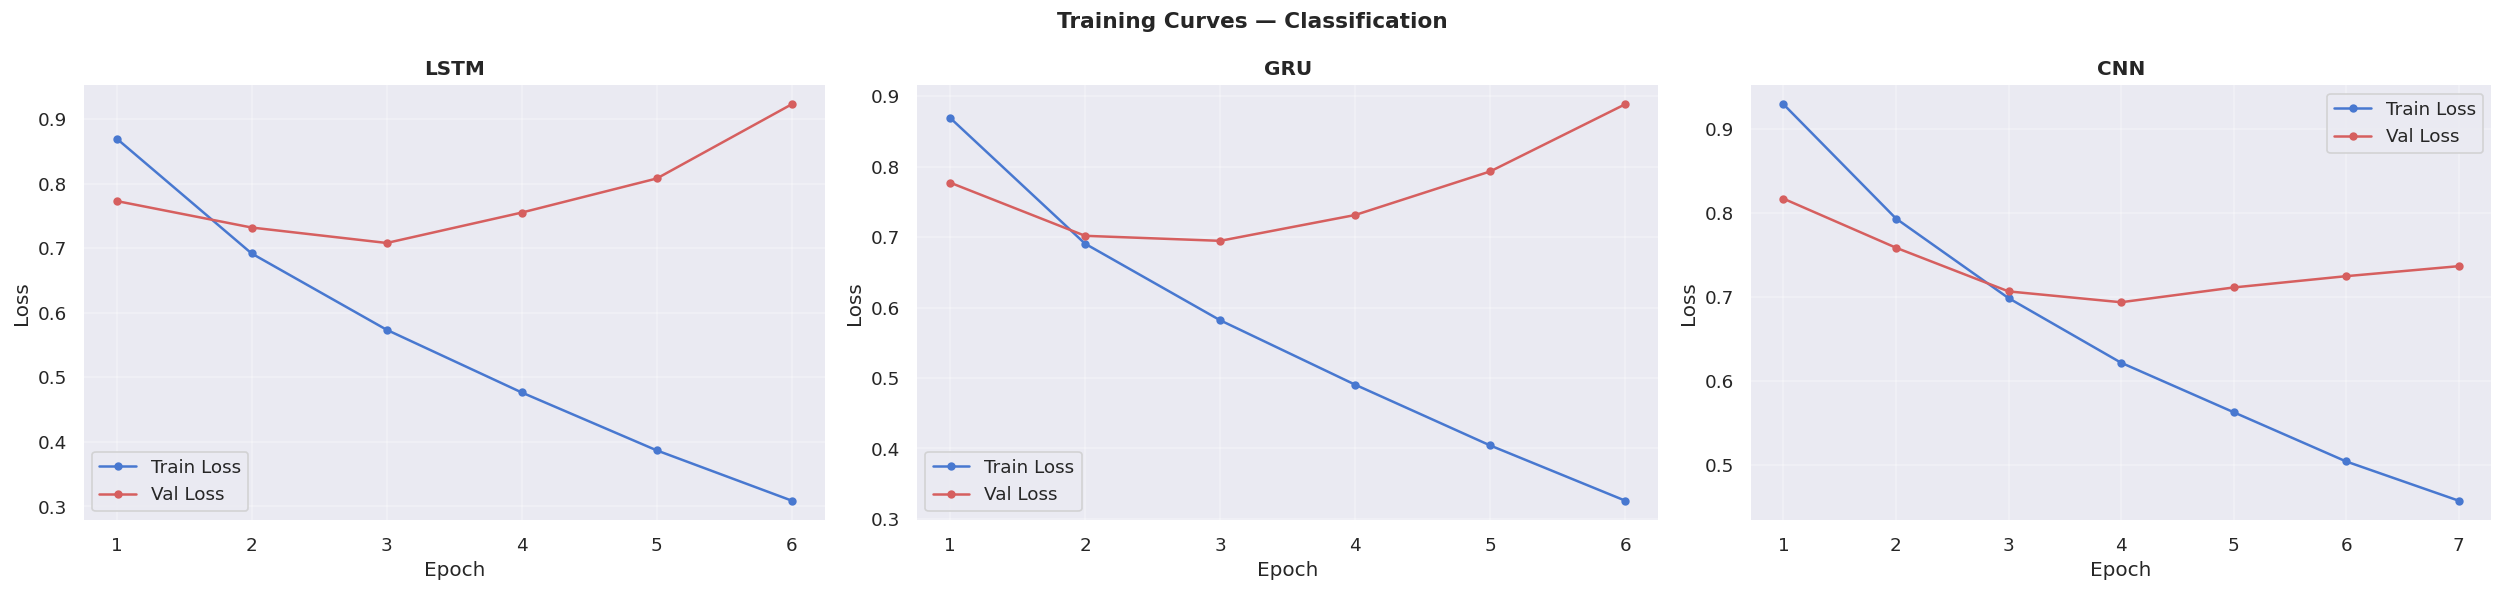

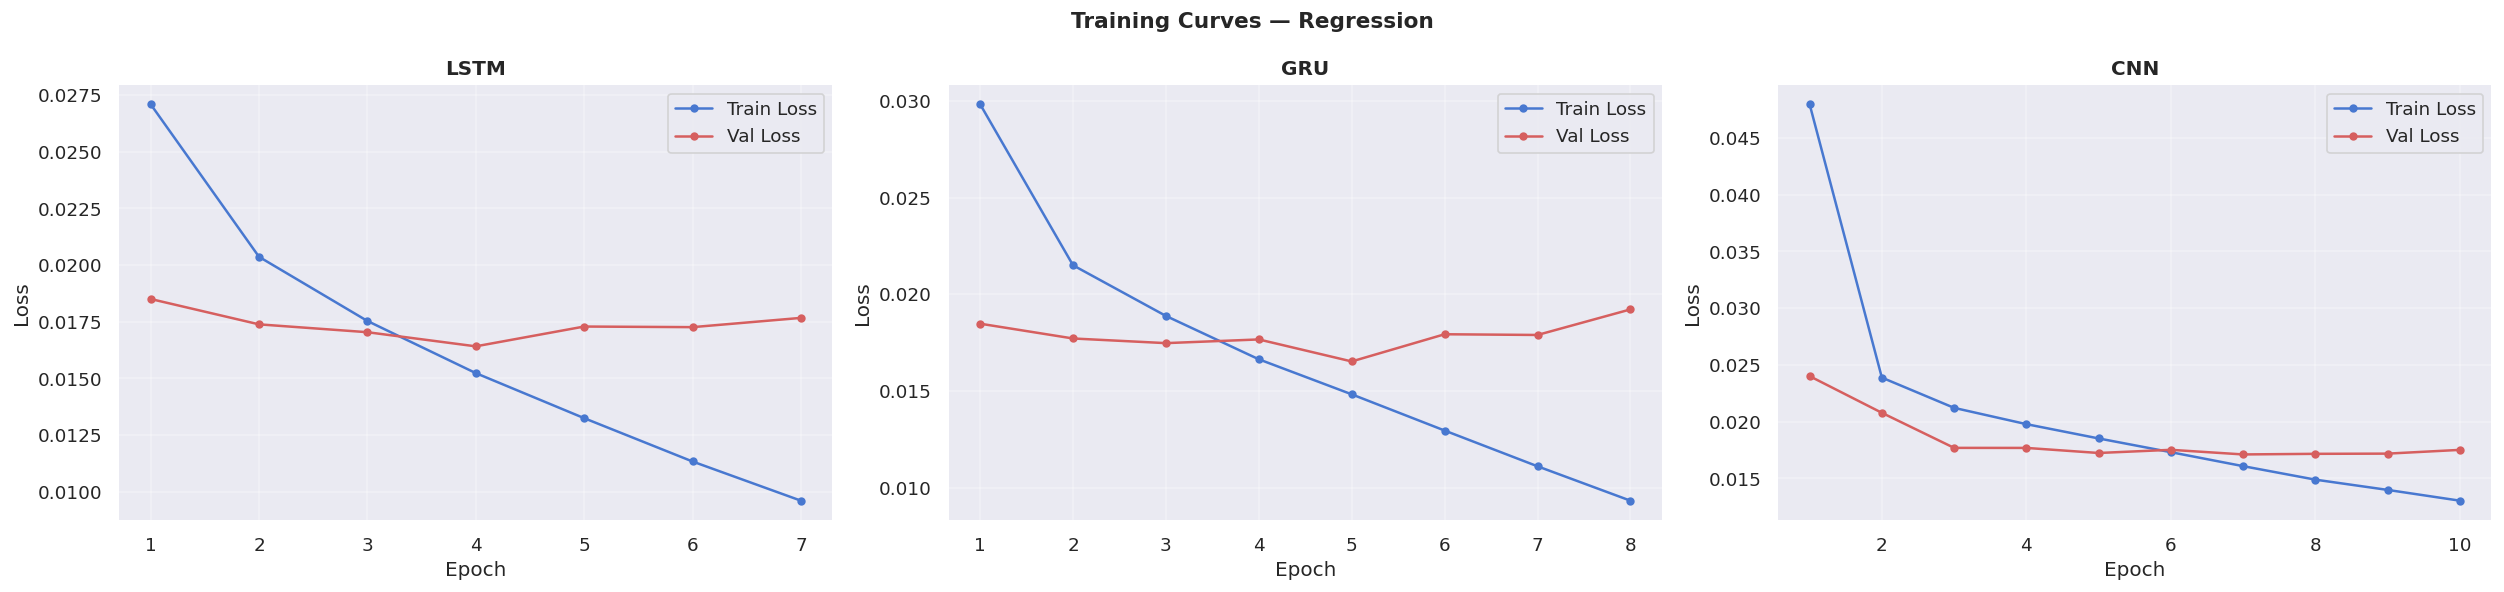

In [65]:
plot_training_curves(
    [hist_lstm_cls, hist_gru_cls, hist_cnn_cls],
    ['LSTM', 'GRU', 'CNN'],
    task='classification'
)

plot_training_curves(
    [hist_lstm_reg, hist_gru_reg, hist_cnn_reg],
    ['LSTM', 'GRU', 'CNN'],
    task='regression'
)

Brojke su ostale prakticno slicne, s tim da je dropout najvise pomogao CNN modelu da smanji prethodno najveci gap koji je postojao izmedju validation i training loss-a, pa je sada CNN dao najbolji rezultat. U sustini, povecalo se trajanje treninga u epohama, povecala se tacnost, ali se povecao i gubitak.

--------------

Probacu da smanjim kompleksnost modela smanjivsi mu broj rekurentnih slojeva.

In [66]:
NUM_LAYERS = 1

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

In [67]:
print('Training LSTM Classification...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Classification...')
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Classification...')
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training LSTM Regression...')
hist_lstm_reg, best_lstm_reg = train_model(
    lstm_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Regression...')
hist_gru_reg, best_gru_reg = train_model(
    gru_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Regression...')
hist_cnn_reg, best_cnn_reg = train_model(
    cnn_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)



Training LSTM Classification...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 4.0s | Train Loss: 0.8828 | Val Loss: 0.7957 | Val Acc: 0.6418 | Val F1: 0.6298
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.0s | Train Loss: 0.7003 | Val Loss: 0.7281 | Val Acc: 0.6802 | Val F1: 0.6594
           Val loss improved → best model saved
Epoch 03/10 | Time: 4.7s | Train Loss: 0.5818 | Val Loss: 0.7035 | Val Acc: 0.6938 | Val F1: 0.6882
           Val loss improved → best model saved
Epoch 04/10 | Time: 4.0s | Train Loss: 0.4883 | Val Loss: 0.7428 | Val Acc: 0.7007 | Val F1: 0.6966
             No improvement (1/3)
Epoch 05/10 | Time: 4.0s | Train Loss: 0.4037 | Val Loss: 0.8094 | Val Acc: 0.7013 | Val F1: 0.6980
             No improvement (2/3)
Epoch 06/10 | Time: 8.5s | Train Loss: 0.3296 | Val Loss: 0.8778 | Val Acc: 0.7010 | Val F1: 0.6991
             No improvement (3/3)

 Early stopping triggered at epoch 6

Best val loss: 0.7035

Tr

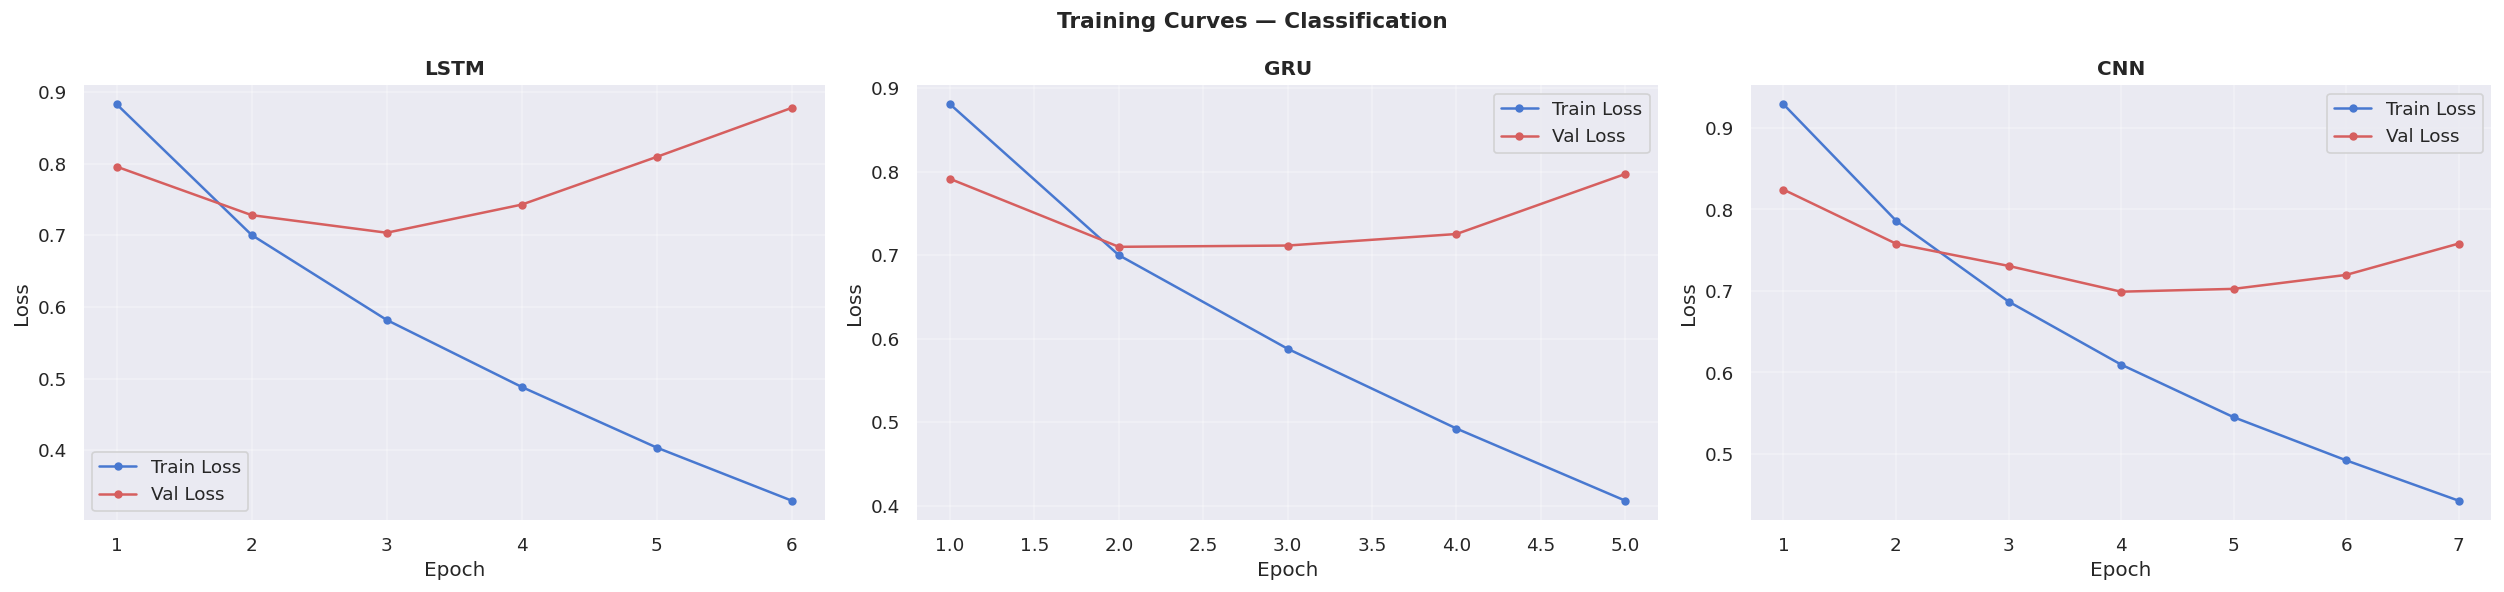

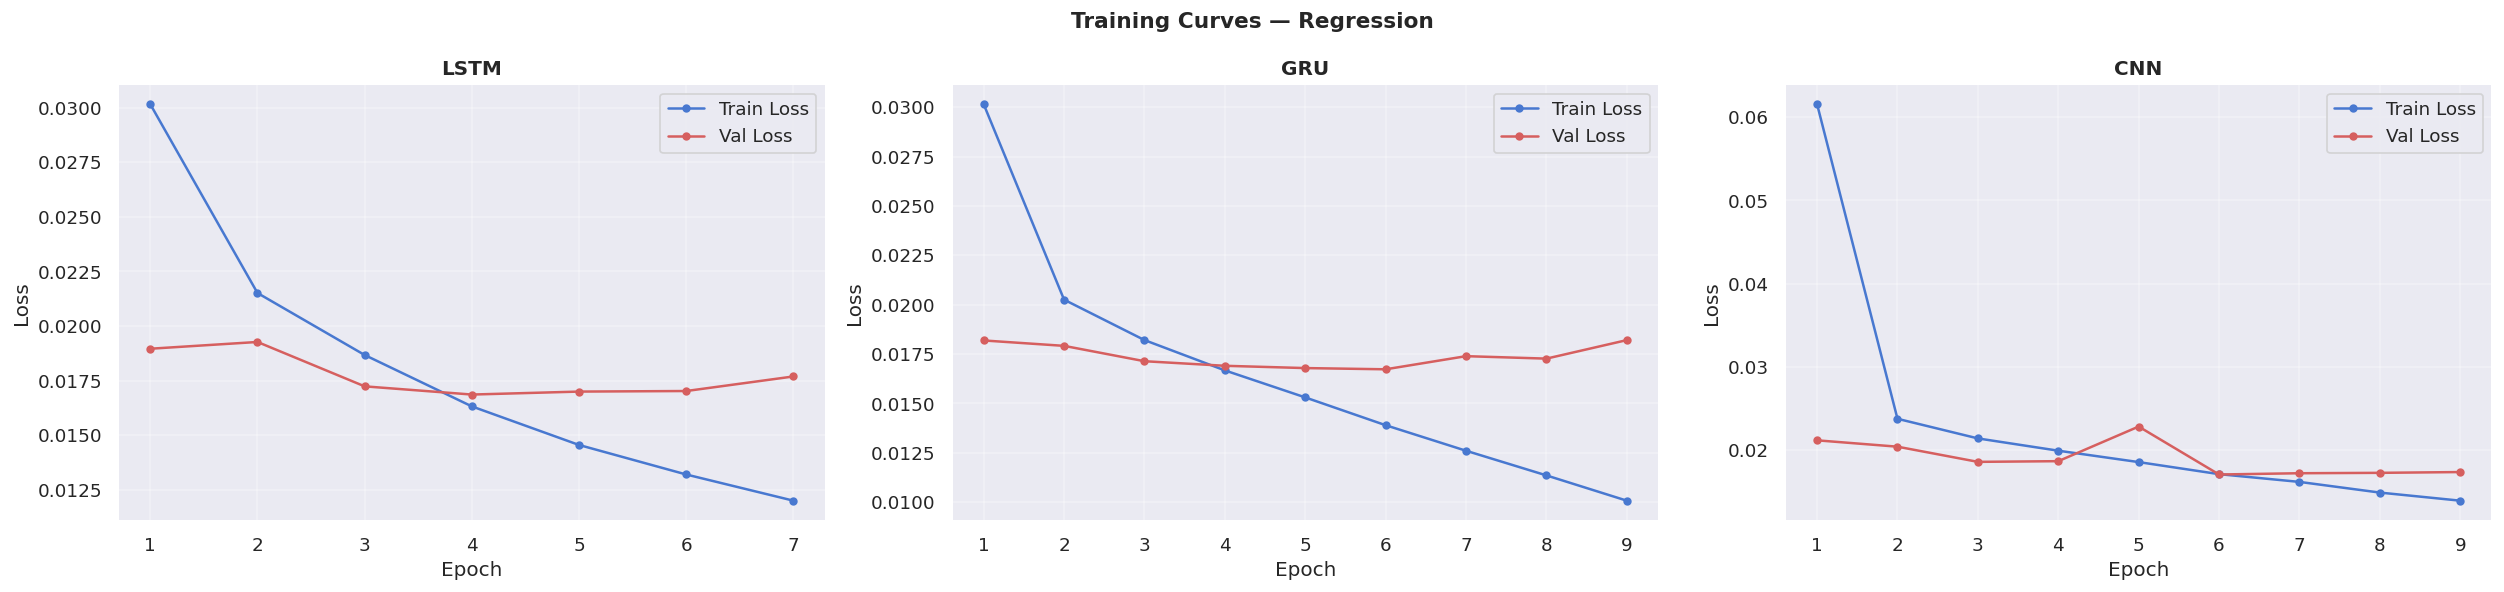

In [68]:
plot_training_curves(
    [hist_lstm_cls, hist_gru_cls, hist_cnn_cls],
    ['LSTM', 'GRU', 'CNN'],
    task='classification'
)

plot_training_curves(
    [hist_lstm_reg, hist_gru_reg, hist_cnn_reg],
    ['LSTM', 'GRU', 'CNN'],
    task='regression'
)

Rezultati su ponovo veoma slici, sto znaci da problem nije u dubini slojeva.

---------------

Smanjivanje kapaciteta modela

In [69]:
HIDDEN_DIM = 64
lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

In [70]:
print('Training LSTM Classification...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Classification...')
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Classification...')
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training LSTM Regression...')
hist_lstm_reg, best_lstm_reg = train_model(
    lstm_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training GRU Regression...')
hist_gru_reg, best_gru_reg = train_model(
    gru_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

print('Training CNN Regression...')
hist_cnn_reg, best_cnn_reg = train_model(
    cnn_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)



Training LSTM Classification...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 4.0s | Train Loss: 0.9088 | Val Loss: 0.8118 | Val Acc: 0.6249 | Val F1: 0.5919
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.6s | Train Loss: 0.7294 | Val Loss: 0.7342 | Val Acc: 0.6697 | Val F1: 0.6656
           Val loss improved → best model saved
Epoch 03/10 | Time: 5.2s | Train Loss: 0.6123 | Val Loss: 0.7091 | Val Acc: 0.6903 | Val F1: 0.6840
           Val loss improved → best model saved
Epoch 04/10 | Time: 3.9s | Train Loss: 0.5246 | Val Loss: 0.7182 | Val Acc: 0.6944 | Val F1: 0.6912
             No improvement (1/3)
Epoch 05/10 | Time: 5.4s | Train Loss: 0.4524 | Val Loss: 0.7546 | Val Acc: 0.6941 | Val F1: 0.6915
             No improvement (2/3)
Epoch 06/10 | Time: 4.2s | Train Loss: 0.3929 | Val Loss: 0.8286 | Val Acc: 0.7005 | Val F1: 0.6960
             No improvement (3/3)

 Early stopping triggered at epoch 6

Best val loss: 0.7091

Tr

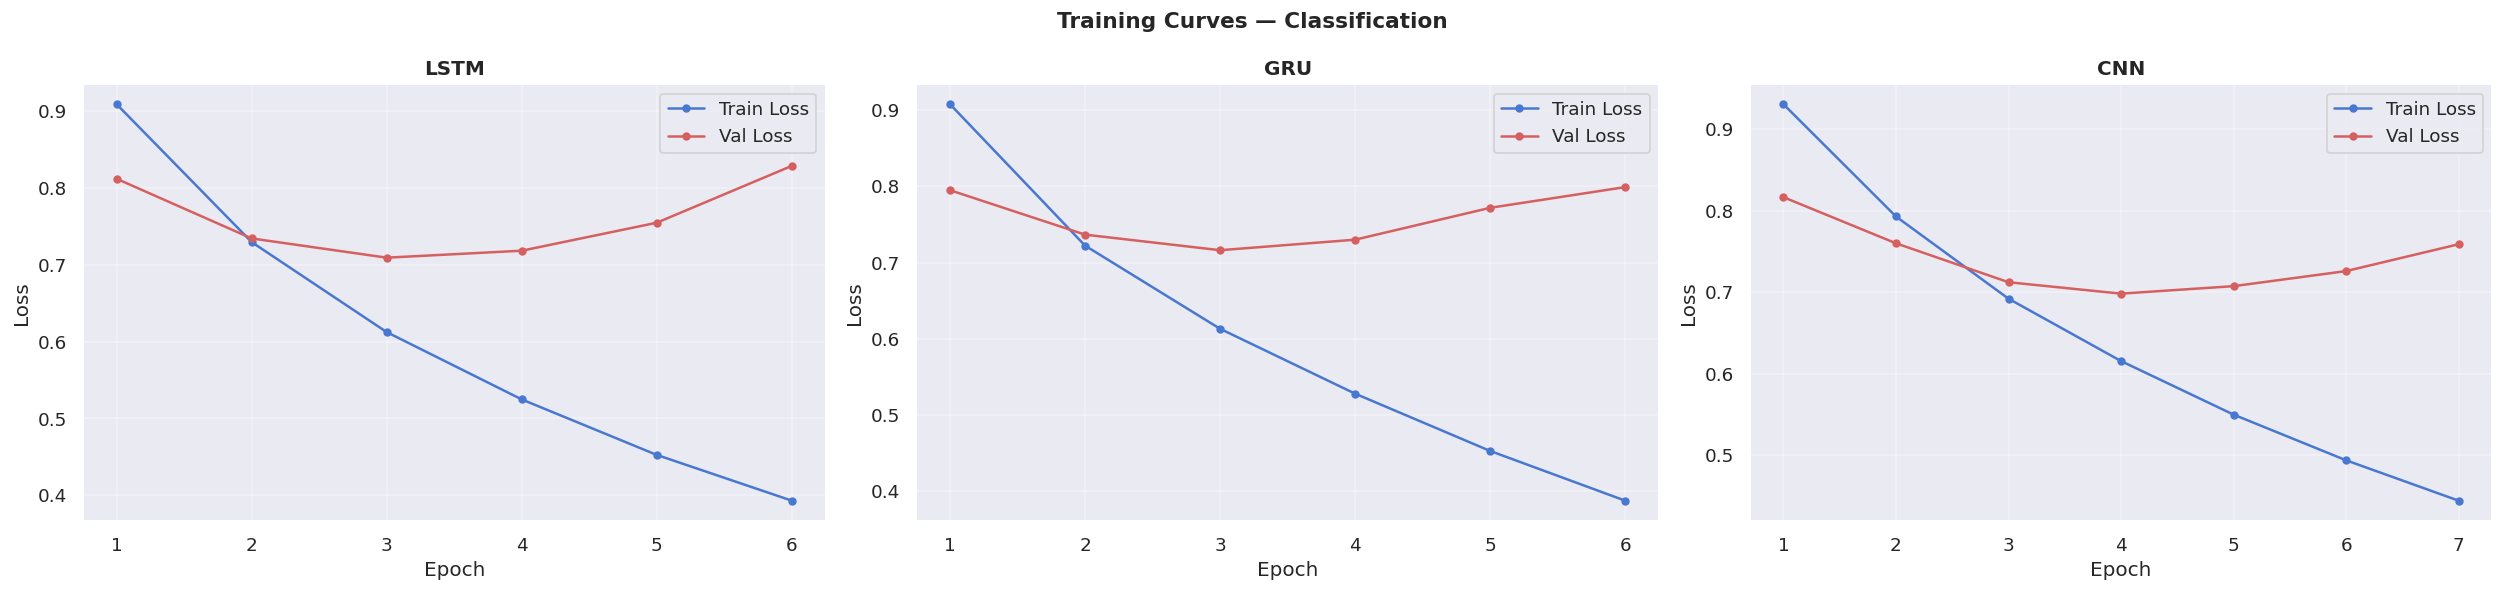

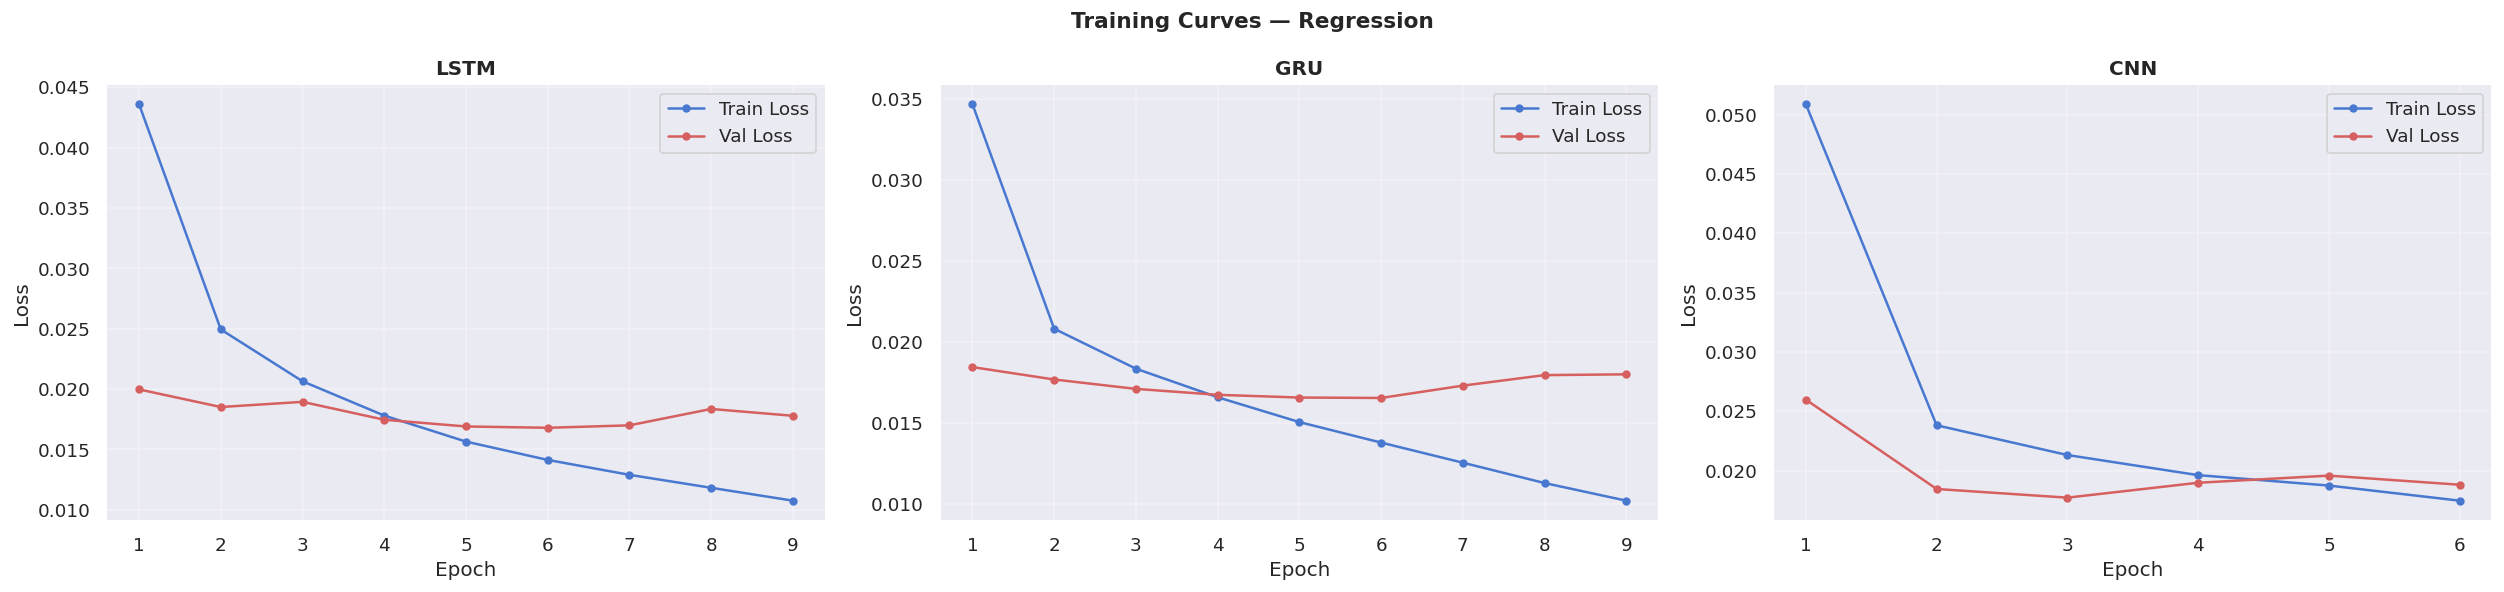

In [71]:
plot_training_curves(
    [hist_lstm_cls, hist_gru_cls, hist_cnn_cls],
    ['LSTM', 'GRU', 'CNN'],
    task='classification'
)

plot_training_curves(
    [hist_lstm_reg, hist_gru_reg, hist_cnn_reg],
    ['LSTM', 'GRU', 'CNN'],
    task='regression'
)

Note: Posto je potrebno da se restartuje kernel i rerunuju celije, a kako mi je istekao trial za GPU na Colab-u, dok je na CPU potrebno oko 2minuta za jednu epohu, necu runovati ove celije zbog prevelikog vremena cekanja. <br>
4 treninga * 2 taska * 3 mreze * 6 epoha (u proseku) * 2min (u proseku) = 288 min = 4h i 48min za trening.

------------------------

# TEST

Na osnovu predhodnih rezultata treninga i validacije, test ce sadrzati sledece hiperparametre:

*   Dropout = 0.5 - videlo se da je dodavanje dropouta uspesno smanjilo gap (overfitting, narocito kod CNN).

*   Broj slojeva = 2 - iako i su performanse slicne i sa jednim slojem, dva sloja su dala malo bolje rezultate za GRU i CNN.

*   Broj dimenzija = 128 - isti razlog kao i kod broja slojeva







### Retrain

In [72]:
DROPOUT    = 0.5
NUM_LAYERS = 2
HIDDEN_DIM = 128
NUM_EPOCHS = 10
VAL_CHECKS = 3

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')
cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

print('Training final models...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
hist_lstm_reg, best_lstm_reg = train_model(
    lstm_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
hist_gru_reg, best_gru_reg = train_model(
    gru_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
hist_cnn_reg, best_cnn_reg = train_model(
    cnn_reg, train_reg_loader, val_reg_loader,
    task='regression', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)

Training final models...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 5.1s | Train Loss: 0.8722 | Val Loss: 0.7757 | Val Acc: 0.6398 | Val F1: 0.6330
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.5s | Train Loss: 0.6904 | Val Loss: 0.7159 | Val Acc: 0.6834 | Val F1: 0.6727
           Val loss improved → best model saved
Epoch 03/10 | Time: 5.1s | Train Loss: 0.5755 | Val Loss: 0.7179 | Val Acc: 0.6934 | Val F1: 0.6820
             No improvement (1/3)
Epoch 04/10 | Time: 4.6s | Train Loss: 0.4752 | Val Loss: 0.7380 | Val Acc: 0.6971 | Val F1: 0.6930
             No improvement (2/3)
Epoch 05/10 | Time: 4.5s | Train Loss: 0.3900 | Val Loss: 0.8012 | Val Acc: 0.6977 | Val F1: 0.6920
             No improvement (3/3)

 Early stopping triggered at epoch 5

Best val loss: 0.7159


  Task: CLASSIFICATION
  Model: GRUModel
  Device: cuda
Epoch 01/10 | Time: 5.0s | Train Loss: 0.8689 | Val Loss: 0.7756 | Val Acc: 0.6551 | Val F1: 0.6350


In [73]:
torch.save(best_lstm_cls, 'best_lstm_cls_gpu.pt')
torch.save(best_gru_cls,  'best_gru_cls_gpu.pt')
torch.save(best_cnn_cls,  'best_cnn_cls_gpu.pt')
torch.save(best_lstm_reg, 'best_lstm_reg.pt')
torch.save(best_gru_reg,  'best_gru_reg.pt')
torch.save(best_cnn_reg,  'best_cnn_reg.pt')

---------------

In [74]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error)

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

lstm_cls.load_state_dict(best_lstm_cls)
gru_cls.load_state_dict(best_gru_cls)
cnn_cls.load_state_dict(best_cnn_cls)

lstm_cls = lstm_cls.to(device)
gru_cls  = gru_cls.to(device)
cnn_cls  = cnn_cls.to(device)

print('Best classification weights restored.')

Best classification weights restored.


In [75]:
def evaluate_test(model, loader, criterion, device, task):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)
            loss        = criterion(predictions, y_batch)
            total_loss += loss.item()

            if task == 'classification':
                preds = torch.argmax(predictions, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
            else:
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)

print('evaluate_test() defined.')

evaluate_test() defined.


### Test

In [76]:
test_loss_lstm, preds_lstm, labels_cls = evaluate_test(
    lstm_cls, test_cls_loader, classification_criterion, device, 'classification'
)
test_loss_gru, preds_gru, _ = evaluate_test(
    gru_cls, test_cls_loader, classification_criterion, device, 'classification'
)
test_loss_cnn, preds_cnn, _ = evaluate_test(
    cnn_cls, test_cls_loader, classification_criterion, device, 'classification'
)

print('Test evaluation complete!')
print(f'  LSTM Test Loss: {test_loss_lstm:.4f}')
print(f'  GRU  Test Loss: {test_loss_gru:.4f}')
print(f'  CNN  Test Loss: {test_loss_cnn:.4f}')

Test evaluation complete!
  LSTM Test Loss: 0.7008
  GRU  Test Loss: 0.6875
  CNN  Test Loss: 0.6903


In [77]:
class_names = ['Negative', 'Neutral', 'Positive']

print('=' * 65)
print('  CLASSIFICATION — TEST SET RESULTS')
print('=' * 65)

results_cls = {}
for name, preds in [('LSTM', preds_lstm),
                    ('GRU',  preds_gru),
                    ('CNN',  preds_cnn)]:
    acc       = accuracy_score(labels_cls, preds)
    f1w       = f1_score(labels_cls, preds, average='weighted')
    f1m       = f1_score(labels_cls, preds, average='macro')
    f1_per    = f1_score(labels_cls, preds, average=None)
    prec_per  = __import__('sklearn.metrics', fromlist=['precision_score']).precision_score(
                    labels_cls, preds, average=None)
    rec_per   = __import__('sklearn.metrics', fromlist=['recall_score']).recall_score(
                    labels_cls, preds, average=None)

    results_cls[name] = {
        'accuracy': acc, 'f1_weighted': f1w,
        'f1_macro': f1m, 'f1_per_class': f1_per
    }

    print(f'\n  {name}:')
    print(f'    Accuracy    : {acc:.4f}')
    print(f'    F1 Weighted : {f1w:.4f}')
    print(f'    F1 Macro    : {f1m:.4f}')
    print(f'    {"Class":<12} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'    {"-"*45}')
    for i, cls in enumerate(class_names):
        print(f'    {cls:<12} {prec_per[i]:>10.4f} {rec_per[i]:>10.4f} {f1_per[i]:>10.4f}')

print('\n' + '=' * 65)

  CLASSIFICATION — TEST SET RESULTS

  LSTM:
    Accuracy    : 0.6896
    F1 Weighted : 0.6799
    F1 Macro    : 0.6307
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.6454     0.4035     0.4965
    Neutral          0.6945     0.8204     0.7522
    Positive         0.6941     0.5996     0.6434

  GRU:
    Accuracy    : 0.6995
    F1 Weighted : 0.6950
    F1 Macro    : 0.6568
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.6413     0.4828     0.5509
    Neutral          0.7166     0.7878     0.7505
    Positive         0.6875     0.6512     0.6689

  CNN:
    Accuracy    : 0.7036
    F1 Weighted : 0.6912
    F1 Macro    : 0.6387
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.6755     0.3877     0.4927
    Neutral          0.6955     0.8548     0.7670
    Positive  

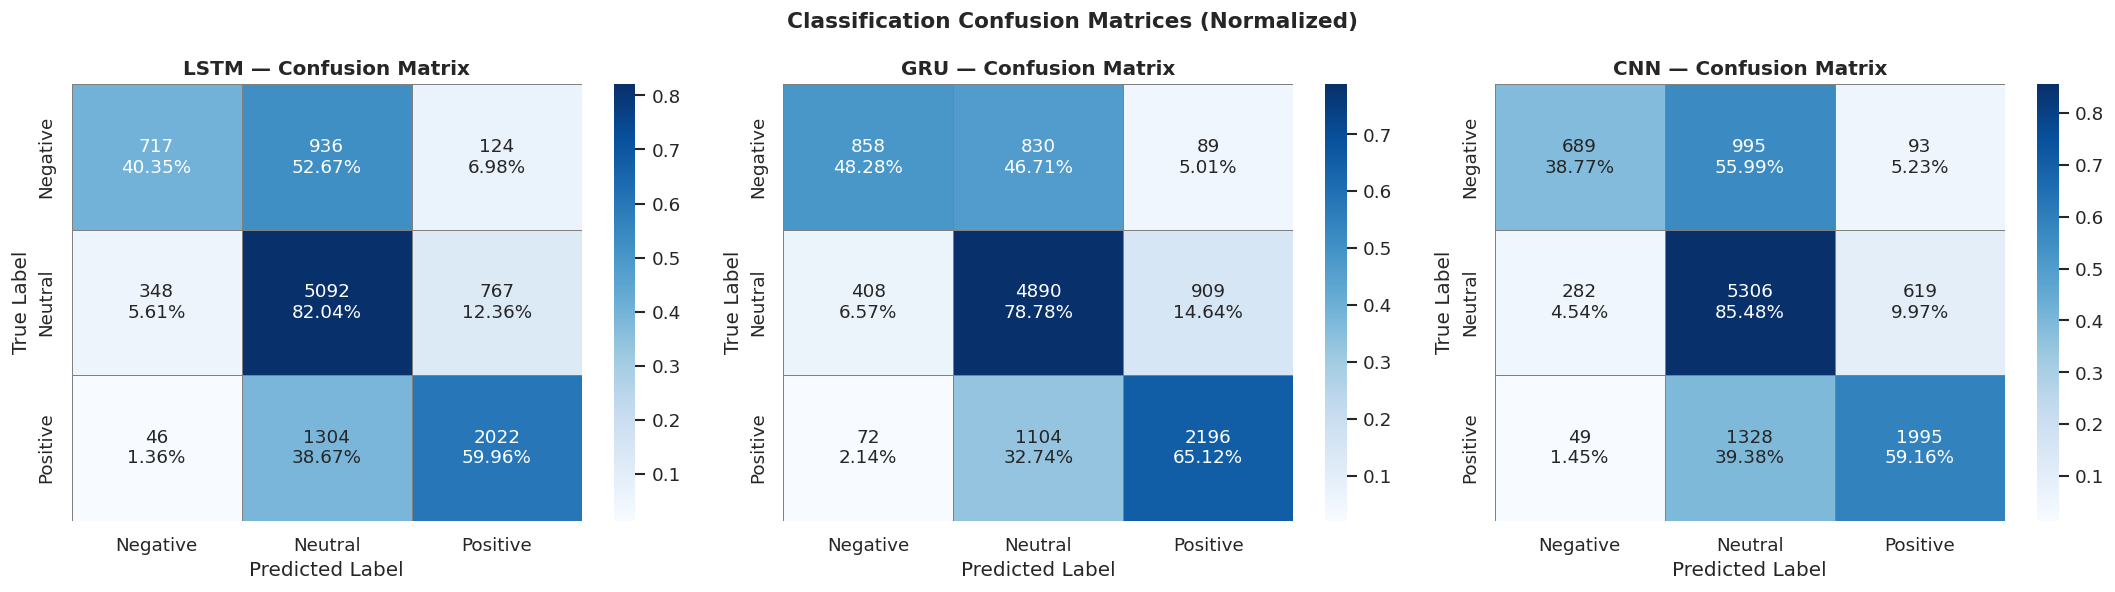

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, preds in zip(axes,
                            ['LSTM', 'GRU', 'CNN'],
                            [preds_lstm, preds_gru, preds_cnn]):
    cm = confusion_matrix(labels_cls, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Build custom annotations: "123\n12.34%"
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n{cm_normalized[i, j]:.2%}'

    sns.heatmap(
        cm_normalized,
        annot=annot,
        fmt='',              # ← empty string since we're using custom annotations
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
        linecolor='gray'
    )
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Classification Confusion Matrices (Normalized)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
print('=' * 60)
print('  FINAL CLASSIFICATION COMPARISON — TEST SET')
print('=' * 60)
print(f'\n  {"Model":<8} {"Accuracy":>10} {"F1 Weighted":>12} {"F1 Macro":>10}')
print(f'  {"-"*45}')
for name in ['LSTM', 'GRU', 'CNN']:
    r = results_cls[name]
    print(f'  {name:<8} {r["accuracy"]:>10.4f} {r["f1_weighted"]:>12.4f} {r["f1_macro"]:>10.4f}')

print(f'\n  Per-class F1:')
print(f'  {"Model":<8} {"Negative":>10} {"Neutral":>10} {"Positive":>10}')
print(f'  {"-"*45}')
for name in ['LSTM', 'GRU', 'CNN']:
    f1 = results_cls[name]['f1_per_class']
    print(f'  {name:<8} {f1[0]:>10.4f} {f1[1]:>10.4f} {f1[2]:>10.4f}')

print('=' * 60)

  FINAL CLASSIFICATION COMPARISON — TEST SET

  Model      Accuracy  F1 Weighted   F1 Macro
  ---------------------------------------------
  LSTM         0.6896       0.6799     0.6307
  GRU          0.6995       0.6950     0.6568
  CNN          0.7036       0.6912     0.6387

  Per-class F1:
  Model      Negative    Neutral   Positive
  ---------------------------------------------
  LSTM         0.4965     0.7522     0.6434
  GRU          0.5509     0.7505     0.6689
  CNN          0.4927     0.7670     0.6564


Kao što se i očekivalo, na performanse modela utiče distribucija klasa. Sva tri modela najbolje rade na neutralnoj (većinskoj klasi) i najviše se muče sa negativnom (manjinskoj klasi, 15,6%). GRU postiže najbolju ukupnu generalizaciju sa najvišim F1 makroom (0,6568) i najboljim F1 po klasi za negativne (0,5509) i pozitivne (0,6689), što ga čini preporučenom arhitekturom za ovaj zadatak. CNN postiže najveću tačnost (0,7036) i neutralni F1 (0,7670), ali je najpristrasniji ka većinskoj klasi, što se vidi po njegovom najnižem negativnom F1 (0,4927). LSTM i CNN pokazuju slične ukupne profile performansi. Dominantni obrazac pogrešne klasifikacije u svim modelima je predviđanje negativnih tvitova kao neutralnih, što odražava stvarnu dvosmislenost između ovih klasa u kratkim tekstovima na društvenim mrežama. Ovo se vidi na matrici konfuzije, gde je vrlo mali broj (5/6%) pogresno klasifikovanih negativnih tweetova, klasifikovano kao pozitivni, a najveci deo na neutralni. Isto vazi i za pogresno klasifikovane pozitivne tweetove. Ovo je zapravo produkt dobre interpretacije modela, jer on uspeva da razlikuje pozitivno od negativnog i obrnuto, ali ima problem sa neutralnim tweetovima koji su vecina dataseta.

# Prediction

In [2]:
new_tweets = [
    # Negative
    ("Bitcoin is crashing hard, I lost everything investing in this garbage.", 0),
    ("Sold all my BTC, this bear market is destroying my portfolio completely.", 0),
    ("Bitcoin is a scam, whales are manipulating the price and retail loses.", 0),
    ("Another brutal red day for Bitcoin, the downtrend shows no signs of stopping.", 0),
    ("Crypto winter is here, Bitcoin dropped below support and looks terrible.", 0),

    # Neutral
    ("Bitcoin trading volume was average today with no major price movements.", 1),
    ("The Bitcoin halving is scheduled for next year according to the blockchain.", 1),
    ("Miners are currently processing around 300,000 Bitcoin transactions per day.", 1),
    ("Bitcoin has been consolidating between 40k and 45k for the past two weeks.", 1),
    ("The Bitcoin network hashrate reached a new all time high this month.", 1),

    # Positive (label = 2)
    ("Bitcoin just broke all time high, this bull run is absolutely incredible!", 2),
    ("Bought more BTC today, this dip is a massive opportunity to accumulate.", 2),
    ("Bitcoin adoption is growing fast, more institutions are buying every week.", 2),
    ("The Lightning Network is making Bitcoin transactions instant and almost free!", 2),
    ("Bitcoin is the best performing asset of the decade, hodlers are winning!", 2),
]



In [ ]:
texts  = [tweet for tweet, label in new_tweets]
labels = [label for tweet, label in new_tweets]


cleaned = [preprocess_tweet(t) for t in texts]

print('=== Original vs Cleaned ===')
for orig, clean in zip(texts, cleaned):
    print(f'  ORIGINAL : {orig}')
    print(f'  CLEANED  : {clean}')
    print()

In [ ]:
def prepare_input(cleaned_tweets, vocab, max_len, pad_idx, unk_idx, device):
        sequences = [
        pad_or_truncate(tokenize(text, vocab, unk_idx), max_len, pad_idx)
        for text in cleaned_tweets
    ]
    return torch.tensor(sequences, dtype=torch.long).to(device)

x_new    = prepare_input(cleaned, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, device)
y_true   = torch.tensor(labels, dtype=torch.long).to(device)

print(f'Input tensor shape : {x_new.shape}  (15 tweets × {MAX_SEQ_LEN} tokens)')
print(f'True labels        : {y_true.tolist()}')

In [ ]:
def predict(model, x, device):
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(logits, dim=1)
    return preds.cpu().numpy(), probs.cpu().numpy()

preds_lstm_new, probs_lstm_new = predict(lstm_cls, x_new, device)
preds_gru_new,  probs_gru_new  = predict(gru_cls,  x_new, device)
preds_cnn_new,  probs_cnn_new  = predict(cnn_cls,  x_new, device)

print('Predictions complete!')

In [ ]:
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('=' * 100)
print('  PREDICTION RESULTS')
print('=' * 100)
print(f'  {"#":<3} {"True":<10} {"LSTM":<10} {"GRU":<10} {"CNN":<10}  Tweet')
print(f'  {"-"*90}')

for i, (tweet, true_label) in enumerate(new_tweets):
    true_name = label_names[true_label]
    lstm_name = label_names[preds_lstm_new[i]]
    gru_name  = label_names[preds_gru_new[i]]
    cnn_name  = label_names[preds_cnn_new[i]]

    lstm_mark = '✅' if preds_lstm_new[i] == true_label else '❌'
    gru_mark  = '✅' if preds_gru_new[i]  == true_label else '❌'
    cnn_mark  = '✅' if preds_cnn_new[i]  == true_label else '❌'

    print(f'  {i+1:<3} {true_name:<10} '
          f'{lstm_name:<8}{lstm_mark}  '
          f'{gru_name:<8}{gru_mark}  '
          f'{cnn_name:<8}{cnn_mark}  '
          f'{tweet[:60]}...')

print('=' * 100)

In [ ]:
print('\n=== Probability Breakdown (GRU) ===')
print(f'  {"#":<3} {"True":<10} {"P(Neg)":>8} {"P(Neu)":>8} {"P(Pos)":>8}  {"Predicted":<10}')
print(f'  {"-"*60}')

for i, (tweet, true_label) in enumerate(new_tweets):
    probs = probs_gru_new[i]
    pred  = label_names[preds_gru_new[i]]
    true  = label_names[true_label]
    mark  = '✅' if preds_gru_new[i] == true_label else '❌'
    print(f'  {i+1:<3} {true:<10} {probs[0]:>8.3f} {probs[1]:>8.3f} {probs[2]:>8.3f}  {pred:<10}{mark}')

In [ ]:
print('\n=== Accuracy on 15 New Tweets ===')
for name, preds in [('LSTM', preds_lstm_new),
                    ('GRU',  preds_gru_new),
                    ('CNN',  preds_cnn_new)]:
    correct = sum(p == t for p, t in zip(preds, labels))
    acc     = correct / len(labels)

    # Per class accuracy
    neg_correct = sum(p == t for p, t in zip(preds, labels) if t == 0)
    neu_correct = sum(p == t for p, t in zip(preds, labels) if t == 1)
    pos_correct = sum(p == t for p, t in zip(preds, labels) if t == 2)

    print(f'\n  {name}:')
    print(f'    Overall  : {correct}/15  ({acc:.1%})')
    print(f'    Negative : {neg_correct}/5')
    print(f'    Neutral  : {neu_correct}/5')
    print(f'    Positive : {pos_correct}/5')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, preds in zip(axes,
                            ['LSTM', 'GRU', 'CNN'],
                            [preds_lstm_new, preds_gru_new, preds_cnn_new]):
    cm = confusion_matrix(labels, preds, labels=[0, 1, 2])

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}'

    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
        linecolor='gray',
        vmin=0,
        vmax=5
    )
    acc = accuracy_score(labels, preds)
    ax.set_title(f'{name} — Confusion Matrix\nAccuracy: {acc:.1%}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Prediction on 15 New Tweets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()